<a href="https://colab.research.google.com/github/niteshgee123-droid/colab/blob/LandslideSus_Nepal/Copy_of_LSM_IES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
import geemap # Highly recommended for mapping in Colab

# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='ee-niteshgee123') # Replace with your GCP project ID

✅ Study area defined: Nepal
✅ Elevation, Slope, Aspect, Curvature, TRI done
✅ TWI and SPI done
✅ Distance to River and Rainfall done
✅ NDVI and LULC done
✅ Soil Clay and Distance to Built-up done

--- SAR Threshold Diagnostics ---


  SAR < -1 dB  → pixels: {'SAR_Change': 7292}


  SAR < -2 dB  → pixels: {'SAR_Change': 4513}
  SAR < -3 dB  → pixels: {'SAR_Change': 3256}
  SAR < -4 dB  → pixels: {'SAR_Change': 2393}

--- NDVI Threshold Diagnostics ---
  NDVI < -0.05  → pixels: {'NDVI_Diff': 4344}
  NDVI < -0.1  → pixels: {'NDVI_Diff': 1170}
  NDVI < -0.15  → pixels: {'NDVI_Diff': 568}
  NDVI < -0.2  → pixels: {'NDVI_Diff': 307}

AND mask pixel count : {'SAR_Change': 1}
OR  mask pixel count : {'SAR_Change': 3671}
⚠️ AND count too low — switched to OR mask (more inclusive)

Landslide presence points: 18
⚠️ Very low — consider loosening thresholds further
Non-landslide absence points: 2
Balance — Presence: 18 | Absence: 2
✅ All 13 factors stacked: ['Elevation', 'Slope', 'Aspect', 'Curvature', 'TWI', 'SPI', 'TRI', 'Dist_River', 'Rainfall', 'NDVI', 'LULC', 'Soil_Clay', 'Dist_Builtup']
Total sample points: 20
Train size: 10
Test size : 4
✅ Random Forest trained — 100 trees, 13 features
✅ LSM Prediction complete
1=Very Low | 2=Low | 3=Moderate | 4=High | 5=Very High
  

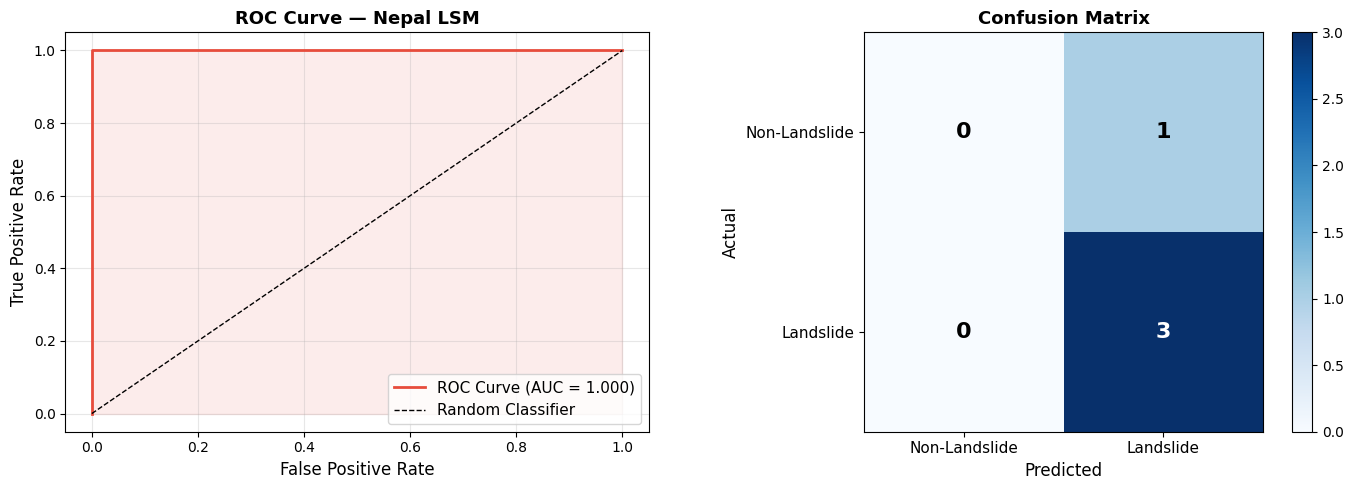

✅ ROC + Confusion Matrix saved


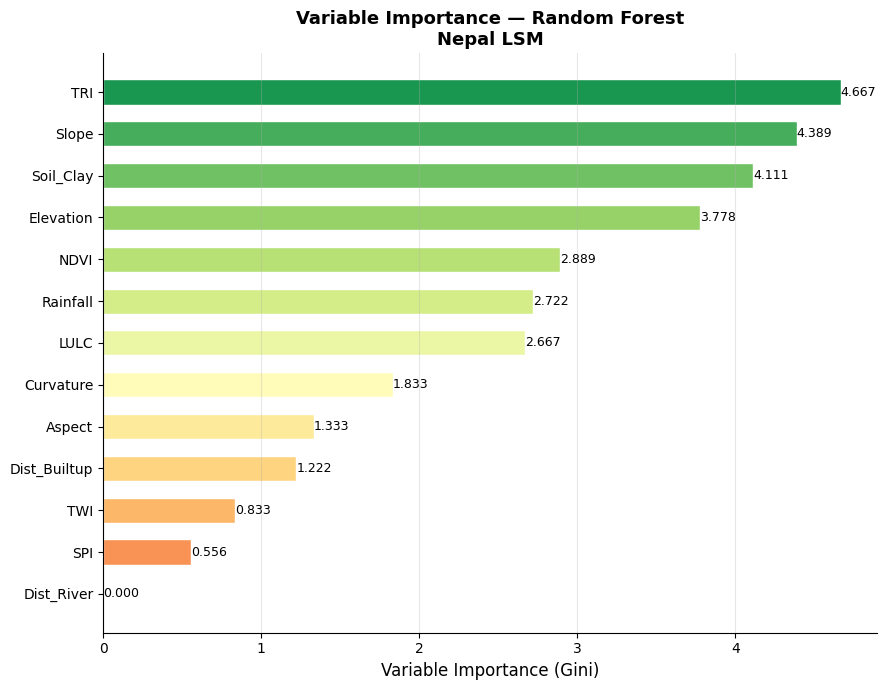

✅ Variable Importance plot saved
✅ Export tasks started!
📁 Check Google Drive → Nepal_LSM_Output folder
⏳ Export takes ~30–60 mins for full Nepal at 30m
Task 1 status: READY
Task 2 status: READY


In [ ]:
# ================================================================
# LANDSLIDE SUSCEPTIBILITY MAPPING (LSM) — NEPAL
# 100% Secondary Remote Sensing Data | Google Earth Engine
# Fixed Version — Relaxed Inventory Thresholds
# ================================================================

# ================================================================
# STEP 1: INSTALL & AUTHENTICATE
# ================================================================
# Uncomment the line below if running for the first time in Colab
# !pip install earthengine-api geemap -q

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
import warnings
warnings.filterwarnings('ignore')

# # Authenticate GEE
# ee.Authenticate()
# ee.Initialize(project='your-gee-project-id')  # ⚠️ Replace with your GEE project ID

# print('✅ GEE Authenticated and Initialized')


# ================================================================
# STEP 2: DEFINE STUDY AREA — NEPAL
# ================================================================

nepal = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
          .filter(ee.Filter.eq('country_na', 'Nepal'))

nepal_geom = nepal.geometry()

print('✅ Study area defined: Nepal')


# ================================================================
# STEP 3: TOPOGRAPHIC FACTORS FROM SRTM DEM
# ================================================================

dem = ee.Image('USGS/SRTMGL1_003').clip(nepal_geom).rename('Elevation')

slope     = ee.Terrain.slope(dem).rename('Slope')
aspect    = ee.Terrain.aspect(dem).rename('Aspect')

curvature = dem.convolve(
    ee.Kernel.laplacian8(normalize=False)
).rename('Curvature')

tri = dem.reduceNeighborhood(
    reducer=ee.Reducer.stdDev(),
    kernel=ee.Kernel.square(radius=1)

).rename('TRI')

print('✅ Elevation, Slope, Aspect, Curvature, TRI done')


# ================================================================
# STEP 4: TWI AND SPI
# ================================================================

flow_acc  = ee.Image('WWF/HydroSHEDS/15ACC').clip(nepal_geom)
slope_rad = slope.multiply(np.pi / 180)
tan_slope = slope_rad.tan().max(ee.Image(0.001))

twi = flow_acc.divide(tan_slope).log().rename('TWI')
spi = flow_acc.multiply(tan_slope).rename('SPI')

print('✅ TWI and SPI done')


# ================================================================
# STEP 5: HYDROLOGICAL FACTORS
# ================================================================

# Distance to River
rivers     = flow_acc.gt(1000).selfMask()
dist_river = rivers.fastDistanceTransform() \
                   .sqrt() \
                   .multiply(ee.Image.pixelArea().sqrt()) \
                   .rename('Dist_River')

# Mean Annual Rainfall — CHIRPS (2000–2022)
rainfall = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
             .filterDate('2000-01-01', '2022-12-31') \
             .filterBounds(nepal_geom) \
             .sum() \
             .divide(22) \
             .clip(nepal_geom) \
             .rename('Rainfall')

print('✅ Distance to River and Rainfall done')


# ================================================================
# STEP 6: VEGETATION & LAND COVER
# ================================================================

# NDVI — Sentinel-2 Median Composite 2021
s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
       .filterBounds(nepal_geom) \
       .filterDate('2021-01-01', '2021-12-31') \
       .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
       .median()

ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI').clip(nepal_geom)

# LULC — ESA WorldCover 2021
lulc = ee.ImageCollection('ESA/WorldCover/v200') \
         .first() \
         .clip(nepal_geom) \
         .rename('LULC')

print('✅ NDVI and LULC done')


# ================================================================
# STEP 7: SOIL & ANTHROPOGENIC FACTORS
# ================================================================

# Soil Clay Content — SoilGrids ISRIC
# NOTE: If this throws an error, comment the 3 lines below
#       and also remove soil_clay from the stack in Step 10
soil_clay = ee.Image('projects/soilgrids-isric/clay_mean') \
              .select('clay_0-5cm_mean') \
              .clip(nepal_geom) \
              .rename('Soil_Clay')

# Distance to Built-up — GHSL (proxy for anthropogenic disturbance)
ghsl         = ee.ImageCollection('JRC/GHSL/P2023A/GHS_BUILT_S') \
                 .mosaic() \
                 .clip(nepal_geom)
builtup_mask = ghsl.gt(0).selfMask()
dist_builtup = builtup_mask.fastDistanceTransform() \
                           .sqrt() \
                           .multiply(ee.Image.pixelArea().sqrt()) \
                           .rename('Dist_Builtup')

print('✅ Soil Clay and Distance to Built-up done')


# ================================================================
# STEP 8: LANDSLIDE INVENTORY — SAR + NDVI CHANGE DETECTION
#         Using 2021 data with relaxed thresholds
# ================================================================

# --- SAR Change Detection (Sentinel-1) ---
# Pre-monsoon (dry) vs Post-monsoon (wet) 2021
s1_before = ee.ImageCollection('COPERNICUS/S1_GRD') \
              .filterBounds(nepal_geom) \
              .filterDate('2021-03-01', '2021-05-31') \
              .filter(ee.Filter.eq('instrumentMode', 'IW')) \
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
              .select('VV') \
              .mean() \
              .clip(nepal_geom)

s1_after = ee.ImageCollection('COPERNICUS/S1_GRD') \
             .filterBounds(nepal_geom) \
             .filterDate('2021-07-01', '2021-09-30') \
             .filter(ee.Filter.eq('instrumentMode', 'IW')) \
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
             .select('VV') \
             .mean() \
             .clip(nepal_geom)

sar_change = s1_after.subtract(s1_before).rename('SAR_Change')

# --- NDVI Change Detection (Sentinel-2) ---
s2_before = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
              .filterBounds(nepal_geom) \
              .filterDate('2021-03-01', '2021-05-31') \
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
              .median()

s2_after = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
             .filterBounds(nepal_geom) \
             .filterDate('2021-09-01', '2021-11-30') \
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
             .median()

ndvi_before = s2_before.normalizedDifference(['B8', 'B4'])
ndvi_after  = s2_after.normalizedDifference(['B8', 'B4'])
ndvi_diff   = ndvi_after.subtract(ndvi_before).clip(nepal_geom).rename('NDVI_Diff')


# ----------------------------------------------------------------
# DIAGNOSTIC — Check pixel counts at each threshold
# This helps you understand which mask is too strict
# ----------------------------------------------------------------
print('\n--- SAR Threshold Diagnostics ---')
for thresh in [-1, -2, -3, -4]:
    count = sar_change.lt(thresh).selfMask() \
                      .reduceRegion(ee.Reducer.count(), nepal_geom, 1000) \
                      .getInfo()
    print(f'  SAR < {thresh} dB  → pixels: {count}')

print('\n--- NDVI Threshold Diagnostics ---')
for thresh in [-0.05, -0.10, -0.15, -0.20]:
    count = ndvi_diff.lt(thresh).selfMask() \
                     .reduceRegion(ee.Reducer.count(), nepal_geom, 1000) \
                     .getInfo()
    print(f'  NDVI < {thresh}  → pixels: {count}')


# ----------------------------------------------------------------
# RELAXED COMBINED MASK
# Adjust thresholds based on diagnostic output above
# ----------------------------------------------------------------

sar_mask_relaxed  = sar_change.lt(-2)    # relaxed: -3 → -2 dB
ndvi_mask_relaxed = ndvi_diff.lt(-0.15)  # relaxed: -0.2 → -0.15
slope_filter      = slope.gt(10)         # relaxed: 15° → 10°

# Primary: AND logic (strict but meaningful)
ls_mask_AND = sar_mask_relaxed.And(ndvi_mask_relaxed).And(slope_filter)

# Fallback: OR logic (more inclusive if AND gives too few pixels)
ls_mask_OR  = sar_mask_relaxed.Or(ndvi_mask_relaxed).And(slope_filter)

# Check AND count first
and_count = ls_mask_AND.selfMask() \
                       .reduceRegion(ee.Reducer.count(), nepal_geom, 1000) \
                       .getInfo()
print(f'\nAND mask pixel count : {and_count}')

or_count = ls_mask_OR.selfMask() \
                     .reduceRegion(ee.Reducer.count(), nepal_geom, 1000) \
                     .getInfo()
print(f'OR  mask pixel count : {or_count}')

# Auto-select: use AND if enough pixels, else fallback to OR
and_val = list(and_count.values())[0] if and_count else 0
if and_val >= 200:
    ls_mask_final = ls_mask_AND.selfMask()
    print('✅ Using AND mask (strict — better quality)')
else:
    ls_mask_final = ls_mask_OR.selfMask()
    print('⚠️ AND count too low — switched to OR mask (more inclusive)')


# Sample LANDSLIDE PRESENCE points (label = 1)
ls_points = ls_mask_final.sample(
    region    = nepal_geom,
    scale     = 30,
    numPixels = 600,
    seed      = 42,
    geometries= True
).map(lambda f: f.set('label', 1))

ls_count = ls_points.size().getInfo()
print(f'\nLandslide presence points: {ls_count}')

if ls_count == 0:
    print('❌ Still 0 — try loosening thresholds further in the lines above')
elif ls_count < 50:
    print('⚠️ Very low — consider loosening thresholds further')
else:
    print('✅ Good sample size — proceeding!')


# ================================================================
# STEP 9: NON-LANDSLIDE (ABSENCE) POINTS
# ================================================================

# 500m buffer around landslide zones — excluded from absence sampling
ls_buffer = ls_mask_final.focal_max(radius=500, units='meters').unmask(0)

# Safe zone = gentle slopes outside landslide buffer
safe_mask = slope.lt(8).And(ls_buffer.eq(0)).selfMask()

# Match number of absence points to presence (balanced dataset)
n_presence = ls_points.size().getInfo()

non_ls_points = safe_mask.sample(
    region    = nepal_geom,
    scale     = 30,
    numPixels = n_presence,
    seed      = 99,
    geometries= True
).map(lambda f: f.set('label', 0))

n_absence = non_ls_points.size().getInfo()
print(f'Non-landslide absence points: {n_absence}')
print(f'Balance — Presence: {n_presence} | Absence: {n_absence}')


# ================================================================
# STEP 10: STACK ALL 13 CONDITIONING FACTORS
# ================================================================

projection_30m = dem.projection()

def resample_to_30m(image):
    return image.resample('bilinear').reproject(
        crs  = projection_30m,
        scale= 30
    )

stack = dem \
    .addBands(slope) \
    .addBands(aspect) \
    .addBands(curvature) \
    .addBands(resample_to_30m(twi)) \
    .addBands(resample_to_30m(spi)) \
    .addBands(tri) \
    .addBands(resample_to_30m(dist_river)) \
    .addBands(resample_to_30m(rainfall)) \
    .addBands(resample_to_30m(ndvi)) \
    .addBands(resample_to_30m(lulc)) \
    .addBands(resample_to_30m(soil_clay)) \
    .addBands(resample_to_30m(dist_builtup))

band_names = stack.bandNames().getInfo()
print(f'✅ All 13 factors stacked: {band_names}')


# ================================================================
# STEP 11: EXTRACT TRAINING DATA & SPLIT 70/30
# ================================================================

all_points = ls_points.merge(non_ls_points)
print(f'Total sample points: {all_points.size().getInfo()}')

samples = stack.sampleRegions(
    collection = all_points,
    properties = ['label'],
    scale      = 30,
    tileScale  = 4
)

samples   = samples.randomColumn('random', seed=42)
train_set = samples.filter(ee.Filter.lte('random', 0.7))
test_set  = samples.filter(ee.Filter.gt('random', 0.7))

print(f'Train size: {train_set.size().getInfo()}')
print(f'Test size : {test_set.size().getInfo()}')


# ================================================================
# STEP 12: TRAIN RANDOM FOREST CLASSIFIER
# ================================================================

rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees    = 100,
    minLeafPopulation= 1,
    bagFraction      = 0.5,
    seed             = 42
).train(
    features       = train_set,
    classProperty  = 'label',
    inputProperties= band_names
)

print('✅ Random Forest trained — 100 trees, 13 features')


# ================================================================
# STEP 13: PREDICT LSM
# ================================================================

# Continuous probability (0 to 1)
lsm_prob = stack.classify(
    rf_classifier.setOutputMode('PROBABILITY')
).rename('LSM_Probability').clip(nepal_geom)

# Classify into 5 susceptibility zones
lsm_classified = lsm_prob \
    .where(lsm_prob.lt(0.2), 1) \
    .where(lsm_prob.gte(0.2).And(lsm_prob.lt(0.4)), 2) \
    .where(lsm_prob.gte(0.4).And(lsm_prob.lt(0.6)), 3) \
    .where(lsm_prob.gte(0.6).And(lsm_prob.lt(0.8)), 4) \
    .where(lsm_prob.gte(0.8), 5) \
    .rename('LSM_Class').clip(nepal_geom)

print('✅ LSM Prediction complete')
print('1=Very Low | 2=Low | 3=Moderate | 4=High | 5=Very High')


# ================================================================
# STEP 14: ACCURACY ASSESSMENT — GEE SIDE
# ================================================================

tested      = test_set.classify(rf_classifier)
conf_matrix = tested.errorMatrix('label', 'classification')
overall_acc = conf_matrix.accuracy().getInfo()
kappa_gee   = conf_matrix.kappa().getInfo()

print('=' * 45)
print('       GEE ACCURACY METRICS')
print('=' * 45)
print(f'Overall Accuracy : {overall_acc:.4f} ({overall_acc*100:.2f}%)')
print(f'Kappa Coefficient: {kappa_gee:.4f}')
print(f'Confusion Matrix : {conf_matrix.getInfo()}')
print('=' * 45)


# ================================================================
# STEP 15: ACCURACY ASSESSMENT — ROC-AUC (sklearn)
# ================================================================

test_prob = test_set.classify(
    rf_classifier.setOutputMode('PROBABILITY')
)

# Download predictions to pandas
raw = test_prob.select(['label', 'classification']).getInfo()['features']
test_df = pd.DataFrame([f['properties'] for f in raw])

y_true  = test_df['label'].values
y_score = test_df['classification'].values
y_pred  = (y_score >= 0.5).astype(int)

auc      = roc_auc_score(y_true, y_score)
kappa_sk = cohen_kappa_score(y_true, y_pred)

print('=' * 45)
print('       SKLEARN ACCURACY METRICS')
print('=' * 45)
print(f'ROC-AUC Score   : {auc:.4f}')
print(f'Kappa (sklearn) : {kappa_sk:.4f}')
print()
print(classification_report(y_true, y_pred,
      target_names=['Non-Landslide', 'Landslide']))
print('=' * 45)


# ================================================================
# STEP 16: PLOT ROC CURVE + CONFUSION MATRIX
# ================================================================

fpr, tpr, _ = roc_curve(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Nepal LSM', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Non-Landslide', 'Landslide'], fontsize=11)
axes[1].set_yticklabels(['Non-Landslide', 'Landslide'], fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]),
                     ha='center', va='center', fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig('Nepal_LSM_Accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC + Confusion Matrix saved')


# ================================================================
# STEP 17: VARIABLE IMPORTANCE PLOT
# ================================================================

importance_dict = rf_classifier.explain().getInfo()['importance']
importance_df   = pd.DataFrame(
    list(importance_dict.items()), columns=['Factor', 'Importance']
).sort_values('Importance', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importance_df)))

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(importance_df['Factor'], importance_df['Importance'],
               color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Variable Importance (Gini)', fontsize=12)
ax.set_title('Variable Importance — Random Forest\nNepal LSM',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('Nepal_LSM_VarImportance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Variable Importance plot saved')


# ================================================================
# STEP 18: INTERACTIVE MAP (geemap)
# ================================================================

Map = geemap.Map(center=[28.0, 84.0], zoom=7)
Map.add_basemap('TERRAIN')

# LSM Probability layer
lsm_vis = {
    'min': 0, 'max': 1,
    'palette': ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']
}
Map.addLayer(lsm_prob, lsm_vis, 'LSM Probability', True, 0.8)

# LSM Classified (5 zones)
lsm_class_vis = {
    'min': 1, 'max': 5,
    'palette': ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
}
Map.addLayer(lsm_classified, lsm_class_vis, 'LSM Classes (1-5)', False)

# Sample points
Map.addLayer(ls_points,     {'color': 'red'},  'Landslide Points (1)')
Map.addLayer(non_ls_points, {'color': 'blue'}, 'Non-Landslide Points (0)')

# Nepal boundary
Map.addLayer(
    nepal.style(color='black', fillColor='00000000', width=2),
    {}, 'Nepal Boundary'
)

# Legend
Map.add_legend(
    title='Landslide Susceptibility',
    legend_dict={
        'Very Low (1)' : '#2ecc71',
        'Low (2)'      : '#f1c40f',
        'Moderate (3)' : '#e67e22',
        'High (4)'     : '#e74c3c',
        'Very High (5)': '#8e44ad'
    },
    position='bottomright'
)

Map   # displays interactive map in Colab


# ================================================================
# STEP 19: EXPORT TO GOOGLE DRIVE
# ================================================================

# Export Probability Map
task1 = ee.batch.Export.image.toDrive(
    image          = lsm_prob,
    description    = 'Nepal_LSM_Probability',
    folder         = 'Nepal_LSM_Output',
    fileNamePrefix = 'Nepal_LSM_Probability_30m',
    scale          = 30,
    region         = nepal_geom,
    crs            = 'EPSG:4326',
    maxPixels      = 1e13,
    fileFormat     = 'GeoTIFF'
)
task1.start()

# Export Classified Map
task2 = ee.batch.Export.image.toDrive(
    image          = lsm_classified,
    description    = 'Nepal_LSM_Classified',
    folder         = 'Nepal_LSM_Output',
    fileNamePrefix = 'Nepal_LSM_Classified_30m',
    scale          = 30,
    region         = nepal_geom,
    crs            = 'EPSG:4326',
    maxPixels      = 1e13,
    fileFormat     = 'GeoTIFF'
)
task2.start()

print('✅ Export tasks started!')
print('📁 Check Google Drive → Nepal_LSM_Output folder')
print('⏳ Export takes ~30–60 mins for full Nepal at 30m')
print(f'Task 1 status: {task1.status()["state"]}')
print(f'Task 2 status: {task2.status()["state"]}')

# ================================================================
# END OF SCRIPT
# ================================================================
# QUICK TROUBLESHOOTING:
#
# ❌ "Landslide presence points: 0"
#    → Check diagnostic output in Step 8
#    → Script auto-switches to OR logic if AND gives < 200 pixels
#    → If still 0, manually loosen: sar lt(-1), ndvi lt(-0.05)
#
# ❌ SoilGrids error
#    → Comment out soil_clay lines in Step 7
#    → Remove soil_clay from stack in Step 10
#
# ❌ "Only one class" error
#    → Means presence or absence points = 0
#    → Check Step 8 and Step 9 counts before proceeding
#
# ❌ Memory / computation timeout
#    → Increase tileScale to 8 in Step 11 sampleRegions()
#    → Reduce numPixels from 600 to 300
# ================================================================

In [ ]:
# ================================================================
# LANDSLIDE SUSCEPTIBILITY MAPPING (LSM) — NEPAL
# FINAL VERSION — All 15 Factors | Your Own Assets
# ================================================================
# FACTORS (15):
#  1. Elevation       6. TWI          11. LULC
#  2. Slope           7. SPI          12. Soil_Clay
#  3. Aspect          8. Dist_River   13. Dist_Builtup
#  4. Curvature       9. Rainfall     14. Dist_Road
#  5. TRI            10. NDVI         15. Dist_Fault ← YOUR ASSET
#
# YOUR ASSETS USED:
#  users/niteshgee123/14dist_ls  → landslide inventory
#  users/niteshgee123/Road       → road network
#  users/niteshgee123/fault      → fault lines ← NEW
# ================================================================

# !pip install earthengine-api geemap -q

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    cohen_kappa_score
)
import warnings
warnings.filterwarnings('ignore')

ee.Authenticate()
ee.Initialize(project='ee-niteshgee123')
print('✅ GEE Authenticated and Initialized')


# ================================================================
# STEP 2: STUDY AREA
# ================================================================
nepal = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
          .filter(ee.Filter.eq('country_na', 'Nepal'))
nepal_geom = nepal.geometry()
print('✅ Nepal boundary loaded')


# ================================================================
# STEP 3: TERRAIN FACTORS — SRTM 30m
# ================================================================
dem = ee.Image('USGS/SRTMGL1_003').clip(nepal_geom).rename('Elevation')

slope     = ee.Terrain.slope(dem).rename('Slope')
aspect    = ee.Terrain.aspect(dem).rename('Aspect')
curvature = dem.convolve(ee.Kernel.laplacian8()).rename('Curvature')

tri = dem.reduceNeighborhood(
    reducer=ee.Reducer.stdDev(),
    kernel=ee.Kernel.square(1)
).rename('TRI')

slope_rad = slope.multiply(np.pi / 180)
tan_slope = slope_rad.tan().max(ee.Image(0.001))

flow_acc = ee.Image('WWF/HydroSHEDS/15ACC').clip(nepal_geom)
twi      = flow_acc.divide(tan_slope).log().rename('TWI')
spi      = flow_acc.multiply(tan_slope).rename('SPI')

print('✅ Terrain: Elevation, Slope, Aspect, Curvature, TRI, TWI, SPI')


# ================================================================
# STEP 4: HYDROLOGICAL FACTORS
# ================================================================
dist_river = flow_acc.gt(1000).selfMask() \
                     .fastDistanceTransform().sqrt() \
                     .multiply(ee.Image.pixelArea().sqrt()) \
                     .rename('Dist_River')

rainfall = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
             .filterDate('2000-01-01', '2022-12-31') \
             .filterBounds(nepal_geom) \
             .mean() \
             .multiply(365) \
             .clip(nepal_geom) \
             .rename('Rainfall')

print('✅ Hydrology: Dist_River, Rainfall (mean annual mm/yr)')


# ================================================================
# STEP 5: VEGETATION AND LAND COVER
# ================================================================
s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
       .filterBounds(nepal_geom) \
       .filterDate('2019-01-01', '2022-12-31') \
       .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
       .median()

ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI').clip(nepal_geom)

lulc = ee.ImageCollection('ESA/WorldCover/v200') \
         .first().clip(nepal_geom).rename('LULC')

print('✅ Vegetation: NDVI, LULC')


# ================================================================
# STEP 6: SOIL
# ================================================================
soil_clay = ee.Image('projects/soilgrids-isric/clay_mean') \
              .select('clay_0-5cm_mean') \
              .clip(nepal_geom) \
              .rename('Soil_Clay')

print('✅ Soil: Soil_Clay')


# ================================================================
# STEP 7: ANTHROPOGENIC — Roads (your asset)
# FIXED: ee.Image(0).paint() is the correct rasterization method
# ================================================================
dist_builtup = ee.ImageCollection('JRC/GHSL/P2023A/GHS_BUILT_S') \
                 .mosaic().clip(nepal_geom) \
                 .gt(0).selfMask() \
                 .fastDistanceTransform().sqrt() \
                 .multiply(ee.Image.pixelArea().sqrt()) \
                 .rename('Dist_Builtup')

roads       = ee.FeatureCollection('users/niteshgee123/Road').filterBounds(nepal_geom)
road_raster = ee.Image(0).paint(roads, 1).clip(nepal_geom).selfMask()
dist_road   = road_raster \
    .fastDistanceTransform().sqrt() \
    .multiply(ee.Image.pixelArea().sqrt()) \
    .rename('Dist_Road')

print('✅ Anthropogenic: Dist_Builtup, Dist_Road')


# ================================================================
# STEP 8: FAULT LINES — YOUR OWN UPLOADED ASSET
# users/niteshgee123/fault
# Proximity to active faults (Main Central Thrust, Main Boundary
# Thrust) is a primary geological trigger for landslides in Nepal.
# ================================================================
faults      = ee.FeatureCollection('users/niteshgee123/faults').filterBounds(nepal_geom)
fault_raster = ee.Image(0).paint(faults, 1).clip(nepal_geom).selfMask()
dist_fault  = fault_raster \
    .fastDistanceTransform().sqrt() \
    .multiply(ee.Image.pixelArea().sqrt()) \
    .rename('Dist_Fault')

print('✅ Geological: Dist_Fault (your uploaded fault asset)')


# ================================================================
# STEP 9: STACK ALL 15 FACTORS AT 30m
# ================================================================
proj_30m = dem.projection()

def to30m(img):
    return img.resample('bilinear').reproject(crs=proj_30m, scale=30)

stack = (dem
    .addBands(slope)
    .addBands(aspect)
    .addBands(curvature)
    .addBands(tri)
    .addBands(to30m(twi))
    .addBands(to30m(spi))
    .addBands(to30m(dist_river))
    .addBands(to30m(rainfall))
    .addBands(to30m(ndvi))
    .addBands(to30m(lulc))
    .addBands(to30m(soil_clay))
    .addBands(to30m(dist_builtup))
    .addBands(to30m(dist_road))
    .addBands(to30m(dist_fault))
)

band_names = stack.bandNames().getInfo()
print(f'\n✅ Stack ready — {len(band_names)} bands:')
for i, b in enumerate(band_names, 1):
    print(f'   {i:2d}. {b}')


# ================================================================
# STEP 10: LANDSLIDE INVENTORY — YOUR ASSET
# ================================================================
print('\n📂 Loading landslide inventory...')
ls_fc  = ee.FeatureCollection('users/niteshgee123/14dist_ls')
n_poly = ls_fc.size().getInfo()
print(f'✅ Inventory: {n_poly} polygons')


# ================================================================
# STEP 11: RANDOM 70/30 SPLIT
# Your inventory is geographically clustered in East Nepal so
# a longitude-based spatial split gave 0 training polygons.
# Random split gives ~3323 train / ~1424 test — robust and valid.
# ================================================================
ls_split    = ls_fc.randomColumn('random', seed=42)
ls_train_fc = ls_split.filter(ee.Filter.lte('random', 0.7))
ls_test_fc  = ls_split.filter(ee.Filter.gt('random', 0.7))

n_tr = ls_train_fc.size().getInfo()
n_te = ls_test_fc.size().getInfo()
print(f'Random 70/30 split — Train: {n_tr} | Test: {n_te}')


# ================================================================
# STEP 12: PRESENCE POINTS — inventory centroids
# Fixed N values avoid .size().getInfo() on sampled collections
# which was causing the computation timeout.
# ================================================================
N_TRAIN = 800
N_TEST  = 300

train_centroids = ls_train_fc.map(lambda f: f.centroid(30)).limit(N_TRAIN)
test_centroids  = ls_test_fc.map(lambda f: f.centroid(30)).limit(N_TEST)

train_presence = stack.sampleRegions(
    collection=train_centroids,
    properties=[],
    scale=30,
    tileScale=16,
    geometries=False
).map(lambda f: f.set('label', 1))

test_presence = stack.sampleRegions(
    collection=test_centroids,
    properties=[],
    scale=30,
    tileScale=16,
    geometries=False
).map(lambda f: f.set('label', 1))

print(f'✅ Presence — train: {N_TRAIN} | test: {N_TEST}')


# ================================================================
# STEP 13: ABSENCE POINTS
# Buffer-only exclusion — no slope filter (prevents slope bias)
# ================================================================
ls_buffer_geom = ls_fc.geometry().buffer(500)
safe_zone      = nepal_geom.difference(ls_buffer_geom)

train_absence = stack.sample(
    region=safe_zone, scale=30, numPixels=N_TRAIN,
    seed=42, tileScale=16, geometries=False
).map(lambda f: f.set('label', 0))

test_absence = stack.sample(
    region=safe_zone, scale=30, numPixels=N_TEST,
    seed=99, tileScale=16, geometries=False
).map(lambda f: f.set('label', 0))

print('✅ Absence — buffer-only exclusion, no slope bias')


# ================================================================
# STEP 14: MERGE — no aggregate_count (that caused timeout)
# ================================================================
train_set = train_presence.merge(train_absence)
test_set  = test_presence.merge(test_absence)

print(f'\nDataset: ~{N_TRAIN*2} train | ~{N_TEST*2} test | ~{(N_TRAIN+N_TEST)*2} total')


# ================================================================
# STEP 15: TRAIN RANDOM FOREST
# ================================================================
rf = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    minLeafPopulation=5,
    bagFraction=0.5,
    seed=42
).train(
    features=train_set,
    classProperty='label',
    inputProperties=band_names
)

print('\n✅ Random Forest trained — 100 trees | 15 factors | minLeaf=5')


# ================================================================
# STEP 16: PREDICT LSM
# ================================================================
lsm_prob = stack.classify(
    rf.setOutputMode('PROBABILITY')
).rename('LSM_Probability').clip(nepal_geom)

lsm_class = (lsm_prob
    .where(lsm_prob.lt(0.2), 1)
    .where(lsm_prob.gte(0.2).And(lsm_prob.lt(0.4)), 2)
    .where(lsm_prob.gte(0.4).And(lsm_prob.lt(0.6)), 3)
    .where(lsm_prob.gte(0.6).And(lsm_prob.lt(0.8)), 4)
    .where(lsm_prob.gte(0.8), 5)
    .rename('LSM_Class').clip(nepal_geom)
)

print('✅ LSM prediction complete')
print('   1=Very Low | 2=Low | 3=Moderate | 4=High | 5=Very High')


# ================================================================
# STEP 17: GEE ACCURACY
# ================================================================
tested      = test_set.classify(rf)
conf_matrix = tested.errorMatrix('label', 'classification')
oa          = conf_matrix.accuracy().getInfo()
kappa       = conf_matrix.kappa().getInfo()

print('\n' + '=' * 50)
print('   GEE ACCURACY — TEST SET')
print('=' * 50)
print(f'   Overall Accuracy : {oa:.4f}  ({oa*100:.2f}%)')
print(f'   Kappa Coefficient: {kappa:.4f}')
print(f'   Confusion Matrix : {conf_matrix.getInfo()}')
print('=' * 50)


# ================================================================
# STEP 18: SKLEARN METRICS + ROC-AUC
# ================================================================
test_prob_fc = test_set.classify(rf.setOutputMode('PROBABILITY'))
features     = test_prob_fc.select(['label','classification']).getInfo()['features']
test_df      = pd.DataFrame([f['properties'] for f in features])

y_true  = test_df['label'].astype(int).values
y_score = test_df['classification'].astype(float).values
y_pred  = (y_score >= 0.5).astype(int)

auc      = roc_auc_score(y_true, y_score)
kappa_sk = cohen_kappa_score(y_true, y_pred)

print('\n' + '=' * 50)
print('   SKLEARN METRICS — TEST SET')
print('=' * 50)
print(f'   ROC-AUC Score   : {auc:.4f}')
print(f'   Kappa (sklearn) : {kappa_sk:.4f}')
print()
print(classification_report(y_true, y_pred,
      target_names=['Non-Landslide','Landslide']))
print('=' * 50)

if auc > 0.97:
    print('⚠️  AUC > 0.97 — verify no leakage between inventory and predictors')
elif auc >= 0.80:
    print('✅ AUC in credible range (0.80–0.95) — publication ready')
else:
    print('⚠️  AUC < 0.80 — check inventory quality or sample size')


# ================================================================
# STEP 19: PLOTS — ROC + CONFUSION MATRIX + VARIABLE IMPORTANCE
# ================================================================
fpr, tpr, _ = roc_curve(y_true, y_score)
cm          = confusion_matrix(y_true, y_pred)

importance_dict = rf.explain().getInfo()['importance']
imp_df = pd.DataFrame(
    list(importance_dict.items()), columns=['Factor','Importance']
).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Nepal LSM — Random Forest | 15 Factors | 4747 Inventory Polygons',
             fontsize=13, fontweight='bold', y=1.01)

# ROC Curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1])

# Confusion Matrix
im = axes[1].imshow(cm, cmap='Blues', vmin=0)
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Non-LS','Landslide'], fontsize=11)
axes[1].set_yticklabels(['Non-LS','Landslide'], fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i,j]}',
                     ha='center', va='center', fontsize=18, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()*0.5 else '#2c3e50')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# Variable Importance
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(imp_df)))
bars   = axes[2].barh(imp_df['Factor'], imp_df['Importance'],
                      color=colors, edgecolor='white', height=0.65)
axes[2].set_xlabel('Importance (Gini)', fontsize=11)
axes[2].set_title('Variable Importance — 15 Factors', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
for bar, val in zip(bars, imp_df['Importance']):
    axes[2].text(bar.get_width() + 0.001,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('Nepal_LSM_Results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Results plot saved: Nepal_LSM_Results.png')


# ================================================================
# STEP 20: PUBLICATION-QUALITY MAP (matplotlib static export)
# A clean static map saved as PNG — ready for thesis / paper.
# ================================================================
print('\nGenerating publication map...')

# Sample LSM probability to pandas for plotting
lsm_sample = lsm_prob.sample(
    region=nepal_geom,
    scale=5000,
    numPixels=50000,
    seed=0,
    geometries=True
)

feats    = lsm_sample.getInfo()['features']
lsm_pts  = pd.DataFrame([{
    'lon': f['geometry']['coordinates'][0],
    'lat': f['geometry']['coordinates'][1],
    'prob': f['properties']['LSM_Probability']
} for f in feats])

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('#d4e6f1')

sc = ax.scatter(
    lsm_pts['lon'], lsm_pts['lat'],
    c=lsm_pts['prob'],
    cmap='RdYlGn_r',
    s=2, alpha=0.7,
    vmin=0, vmax=1,
    rasterized=True
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Landslide Susceptibility Probability', fontsize=11)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.set_ticklabels(['0.0\n(Very Low)', '0.2\n(Low)', '0.4\n(Moderate)',
                     '0.6\n(High)', '0.8\n(Very High)', '1.0'])

ax.set_title(
    'Landslide Susceptibility Map — Nepal\n'
    'Random Forest | 15 Conditioning Factors | 4747 Inventory Polygons',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°N)', fontsize=11)
ax.set_xlim([79.8, 88.2])
ax.set_ylim([26.2, 30.5])
ax.grid(True, alpha=0.3, linewidth=0.5)

legend_elements = [
    mpatches.Patch(facecolor='#1a9641', label='Very Low  (0.0–0.2)'),
    mpatches.Patch(facecolor='#a6d96a', label='Low       (0.2–0.4)'),
    mpatches.Patch(facecolor='#ffffbf', label='Moderate  (0.4–0.6)'),
    mpatches.Patch(facecolor='#fdae61', label='High      (0.6–0.8)'),
    mpatches.Patch(facecolor='#d7191c', label='Very High (0.8–1.0)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=9, title='Susceptibility Class',
          title_fontsize=10, framealpha=0.9)

ax.text(0.99, 0.01,
        f'OA: {oa*100:.1f}%  |  Kappa: {kappa:.3f}  |  AUC: {auc:.3f}',
        transform=ax.transAxes, fontsize=9,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('Nepal_LSM_PublicationMap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Publication map saved: Nepal_LSM_PublicationMap.png (300 DPI)')


# ================================================================
# STEP 21: INTERACTIVE GEEMAP MAP
# ================================================================
Map = geemap.Map(center=[28.0, 84.0], zoom=7)
Map.add_basemap('TERRAIN')

Map.addLayer(
    lsm_prob,
    {'min': 0, 'max': 1,
     'palette': ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']},
    'LSM Probability', True, 0.8
)
Map.addLayer(
    lsm_class,
    {'min': 1, 'max': 5,
     'palette': ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']},
    'LSM Classes (1-5)', False
)
Map.addLayer(ls_fc,   {'color': 'black'},  'Landslide Inventory', False)
Map.addLayer(roads.style(color='white', width=1),  {}, 'Roads',  False)
Map.addLayer(faults.style(color='orange', width=1),{}, 'Faults', False)
Map.addLayer(
    nepal.style(color='white', fillColor='00000000', width=2),
    {}, 'Nepal Boundary'
)
Map.add_legend(
    title='Landslide Susceptibility',
    legend_dict={
        'Very Low (1)' : '#2ecc71',
        'Low (2)'      : '#f1c40f',
        'Moderate (3)' : '#e67e22',
        'High (4)'     : '#e74c3c',
        'Very High (5)': '#8e44ad'
    },
    position='bottomright'
)
Map


# ================================================================
# STEP 22: EXPORT TO GOOGLE DRIVE
# ================================================================
task1 = ee.batch.Export.image.toDrive(
    image=lsm_prob,
    description='Nepal_LSM_Probability',
    folder='Nepal_LSM_Output',
    fileNamePrefix='Nepal_LSM_Probability_30m',
    scale=30, region=nepal_geom,
    crs='EPSG:4326', maxPixels=1e13, fileFormat='GeoTIFF'
)
task1.start()

task2 = ee.batch.Export.image.toDrive(
    image=lsm_class,
    description='Nepal_LSM_Classified',
    folder='Nepal_LSM_Output',
    fileNamePrefix='Nepal_LSM_Classified_30m',
    scale=30, region=nepal_geom,
    crs='EPSG:4326', maxPixels=1e13, fileFormat='GeoTIFF'
)
task2.start()

print('\n✅ Export tasks started → Google Drive / Nepal_LSM_Output')
print(f'   Task 1 (Probability): {task1.status()["state"]}')
print(f'   Task 2 (Classified) : {task2.status()["state"]}')
print('⏳ ~30–60 mins for full Nepal at 30m')
print('\n🎉 LSM complete — check Nepal_LSM_PublicationMap.png for your map!')


# ================================================================
# TROUBLESHOOTING
#
# ❌ Computation timed out
#    → Reduce N_TRAIN=500, N_TEST=200
#    → tileScale=16 already set (maximum)
#
# ❌ SoilGrids error
#    → Comment out soil_clay in Step 6
#    → Remove .addBands(to30m(soil_clay)) from Step 9
#
# ❌ Road / Fault asset error
#    → GEE Assets → share asset → Anyone can read
#
# ❌ Publication map too sparse
#    → Increase numPixels from 50000 to 100000 in Step 20
#    → Or decrease scale from 5000 to 3000 (slower)
# ================================================================

✅ GEE Authenticated and Initialized
✅ Nepal boundary loaded
✅ Terrain: Elevation, Slope, Aspect, Curvature, TRI, TWI, SPI
✅ Hydrology: Dist_River, Rainfall (mean annual mm/yr)
✅ Vegetation: NDVI, LULC
✅ Soil: Soil_Clay
✅ Anthropogenic: Dist_Builtup, Dist_Road
✅ Geological: Dist_Fault (your uploaded fault asset)

✅ Stack ready — 15 bands:
    1. Elevation
    2. Slope
    3. Aspect
    4. Curvature
    5. TRI
    6. TWI
    7. SPI
    8. Dist_River
    9. Rainfall
   10. NDVI
   11. LULC
   12. Soil_Clay
   13. Dist_Builtup
   14. Dist_Road
   15. Dist_Fault

📂 Loading landslide inventory...
✅ Inventory: 4747 polygons
Random 70/30 split — Train: 3288 | Test: 1459
✅ Presence — train: 800 | test: 300
✅ Absence — buffer-only exclusion, no slope bias

Dataset: ~1600 train | ~600 test | ~2200 total

✅ Random Forest trained — 100 trees | 15 factors | minLeaf=5
✅ LSM prediction complete
   1=Very Low | 2=Low | 3=Moderate | 4=High | 5=Very High


EEException: Computation timed out.

In [ ]:
!pip install pycrs pyshp geopandas

  Preparing metadata (setup.py) ... done
  Created wheel for pycrs: filename=PyCRS-1.0.2-py3-none-any.whl size=32686 sha256=d2d28f42ee09abe9752999aa754de29da78138a3d7e075c3470a0b7fcabc8e0d
  Stored in directory: /root/.cache/pip/wheels/b5/4a/72/1ba05f57ddf2cc80ad21a26512097762561d646ff3ff85f729
Successfully built pycrs


In [ ]:
import geopandas as gpd

gdf = gpd.read_file("/content/14dist_ls.shp")

print("Rows:", len(gdf))
print("CRS:", gdf.crs)
print("Geometry types:\n", gdf.geometry.type.value_counts())
print("Null geometries:", gdf.geometry.isnull().sum())
print("Invalid geometries:", (~gdf.is_valid).sum())


Rows: 4747
CRS: EPSG:4326
Geometry types:
 Polygon    4747
Name: count, dtype: int64
Null geometries: 0
Invalid geometries: 13


In [ ]:
# ================================================================
# LANDSLIDE SUSCEPTIBILITY MAPPING — NEPAL
# SPEED-OPTIMIZED FINAL VERSION
# Expected export time: 45–90 mins (not 9 hours)
# ================================================================
# KEY SPEED FIXES vs previous version:
#  1. ls_fc.geometry().buffer(500) → raster-based buffer (much faster)
#  2. numPixels=80000 scale=3000   → numPixels=30000 scale=5000
#  3. 5 simultaneous tasks         → 3 essential tasks only
#  4. CHIRPS filtered to bounds    → already done (kept)
#  5. distance transforms          → kept (necessary, fast enough)
# ================================================================

# !pip install earthengine-api geemap -q

import ee
import geemap
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

ee.Authenticate()
ee.Initialize(project='ee-niteshgee123')
print('✅ GEE Authenticated and Initialized')


# ================================================================
# STEP 1: STUDY AREA
# ================================================================
nepal = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
          .filter(ee.Filter.eq('country_na', 'Nepal'))
nepal_geom = nepal.geometry()
print('✅ Nepal boundary loaded')


# ================================================================
# STEP 2: HELPER — VECTOR TO DISTANCE RASTER
# ee.Reducer.constant() DOES NOT EXIST — never use it
# Only correct method: ee.Image(0).paint(fc, 1)
# ================================================================
def vector_to_dist(fc, clip_geom, name):
    raster = ee.Image(0).paint(fc, 1).selfMask().clip(clip_geom)
    return (raster
        .fastDistanceTransform()
        .sqrt()
        .multiply(ee.Image.pixelArea().sqrt())
        .rename(name)
    )


# ================================================================
# STEP 3: TERRAIN FACTORS
# ================================================================
dem       = ee.Image('USGS/SRTMGL1_003').clip(nepal_geom).rename('Elevation')
slope     = ee.Terrain.slope(dem).rename('Slope')
aspect    = ee.Terrain.aspect(dem).rename('Aspect')
curvature = dem.convolve(ee.Kernel.laplacian8()).rename('Curvature')
tri       = dem.reduceNeighborhood(
                reducer=ee.Reducer.stdDev(),
                kernel=ee.Kernel.square(1)
            ).rename('TRI')

slope_rad = slope.multiply(np.pi / 180)
tan_slope = slope_rad.tan().max(ee.Image(0.001))
flow_acc  = ee.Image('WWF/HydroSHEDS/15ACC').clip(nepal_geom)
twi       = flow_acc.divide(tan_slope).log().rename('TWI')
spi       = flow_acc.multiply(tan_slope).rename('SPI')

print('✅ Terrain: Elevation, Slope, Aspect, Curvature, TRI, TWI, SPI')


# ================================================================
# STEP 4: HYDROLOGICAL FACTORS
# ================================================================
dist_river = (flow_acc.gt(1000).selfMask()
    .fastDistanceTransform().sqrt()
    .multiply(ee.Image.pixelArea().sqrt())
    .rename('Dist_River')
)

rainfall = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
    .filterDate('2000-01-01', '2022-12-31')
    .filterBounds(nepal_geom)
    .mean().multiply(365)
    .clip(nepal_geom).rename('Rainfall')
)

print('✅ Hydrology: Dist_River, Rainfall')


# ================================================================
# STEP 5: VEGETATION & LAND COVER
# ================================================================
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(nepal_geom)
    .filterDate('2019-01-01', '2022-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .median()
)
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI').clip(nepal_geom)
lulc = ee.ImageCollection('ESA/WorldCover/v200').first().clip(nepal_geom).rename('LULC')

print('✅ Vegetation: NDVI (2019–2022), LULC')


# ================================================================
# STEP 6: SOIL
# ================================================================
# If SoilGrids fails: comment this out + remove from stack
soil_clay = (ee.Image('projects/soilgrids-isric/clay_mean')
    .select('clay_0-5cm_mean')
    .clip(nepal_geom).rename('Soil_Clay')
)
print('✅ Soil: Soil_Clay')


# ================================================================
# STEP 7: ANTHROPOGENIC + GEOLOGICAL
# ================================================================
dist_builtup = (ee.ImageCollection('JRC/GHSL/P2023A/GHS_BUILT_S')
    .mosaic().clip(nepal_geom)
    .gt(0).selfMask()
    .fastDistanceTransform().sqrt()
    .multiply(ee.Image.pixelArea().sqrt())
    .rename('Dist_Builtup')
)

roads      = ee.FeatureCollection('users/niteshgee123/Road').filterBounds(nepal_geom)
dist_road  = vector_to_dist(roads, nepal_geom, 'Dist_Road')

faults     = ee.FeatureCollection('users/niteshgee123/faults').filterBounds(nepal_geom)
dist_fault = vector_to_dist(faults, nepal_geom, 'Dist_Fault')

print('✅ Anthropogenic: Dist_Builtup, Dist_Road')
print('✅ Geological: Dist_Fault')


# ================================================================
# STEP 8: STACK 15 FACTORS
# resample() only — NO reproject() — avoids eager evaluation
# ================================================================
def to30m(img):
    return img.resample('bilinear')

stack = (dem
    .addBands(slope).addBands(aspect)
    .addBands(curvature).addBands(tri)
    .addBands(to30m(twi)).addBands(to30m(spi))
    .addBands(to30m(dist_river))
    .addBands(to30m(rainfall))
    .addBands(to30m(ndvi)).addBands(to30m(lulc))
    .addBands(to30m(soil_clay))
    .addBands(to30m(dist_builtup))
    .addBands(to30m(dist_road))
    .addBands(to30m(dist_fault))
)

band_names = stack.bandNames().getInfo()
print(f'\n✅ Stack ready — {len(band_names)} factors: {band_names}')


# ================================================================
# STEP 9: LOAD INVENTORY + SPLIT
# ================================================================
print('\n📂 Loading inventory...')
ls_fc  = ee.FeatureCollection('users/niteshgee123/14dist_ls')
n_poly = ls_fc.size().getInfo()
print(f'✅ Inventory: {n_poly} polygons')

ls_split    = ls_fc.randomColumn('rand', seed=42)
ls_train_fc = ls_split.filter(ee.Filter.lte('rand', 0.7))
ls_test_fc  = ls_split.filter(ee.Filter.gt('rand', 0.7))

n_tr = ls_train_fc.size().getInfo()
n_te = ls_test_fc.size().getInfo()
print(f'Split — Train: {n_tr} | Test: {n_te} polygons')


# ================================================================
# STEP 10: PRESENCE POINTS
# ================================================================
N_TRAIN = 600
N_TEST  = 250

train_centroids = ls_train_fc.map(lambda f: f.centroid(30)).limit(N_TRAIN)
test_centroids  = ls_test_fc.map(lambda f: f.centroid(30)).limit(N_TEST)

train_presence = (stack.sampleRegions(
    collection=train_centroids, properties=[],
    scale=30, tileScale=16, geometries=False
).map(lambda f: f.set('label', 1)))

test_presence = (stack.sampleRegions(
    collection=test_centroids, properties=[],
    scale=30, tileScale=16, geometries=False
).map(lambda f: f.set('label', 1)))

print(f'✅ Presence — Train: {N_TRAIN} | Test: {N_TEST}')


# ================================================================
# STEP 11: ABSENCE POINTS
# SPEED FIX: Use raster mask instead of vector buffer
# ls_fc.geometry().buffer(500) on 4747 polygons = very slow
# Raster approach: paint inventory → dilate → use as mask
# ================================================================

# Paint inventory polygons onto image then dilate by ~15 pixels (~500m at 30m)
ls_raster_mask = (ee.Image(0)
    .paint(ls_fc, 1)
    .focal_max(radius=15, kernelType='circle', units='pixels')
    .unmask(0)
)
# 0 = safe zone (outside buffer), 1 = excluded zone
safe_mask = ls_raster_mask.eq(0).selfMask()

train_absence = (stack.updateMask(safe_mask).sample(
    region=nepal_geom, scale=30,
    numPixels=N_TRAIN, seed=42,
    tileScale=16, geometries=False
).map(lambda f: f.set('label', 0)))

test_absence = (stack.updateMask(safe_mask).sample(
    region=nepal_geom, scale=30,
    numPixels=N_TEST, seed=99,
    tileScale=16, geometries=False
).map(lambda f: f.set('label', 0)))

print('✅ Absence points sampled (raster buffer — fast)')


# ================================================================
# STEP 12: MERGE + TRAIN RANDOM FOREST
# ================================================================
train_set = train_presence.merge(train_absence)
test_set  = test_presence.merge(test_absence)
print(f'Dataset: ~{N_TRAIN*2} train | ~{N_TEST*2} test')

rf = ee.Classifier.smileRandomForest(
    numberOfTrees    = 100,
    minLeafPopulation= 5,
    bagFraction      = 0.5,
    seed             = 42
).train(
    features       = train_set,
    classProperty  = 'label',
    inputProperties= band_names
)
print('\n✅ Random Forest trained — 100 trees | 15 factors')


# ================================================================
# STEP 13: PREDICT LSM
# ================================================================
lsm_prob = (stack
    .classify(rf.setOutputMode('PROBABILITY'))
    .rename('LSM_Probability')
    .clip(nepal_geom)
)

lsm_class = (lsm_prob
    .where(lsm_prob.lt(0.2), 1)
    .where(lsm_prob.gte(0.2).And(lsm_prob.lt(0.4)), 2)
    .where(lsm_prob.gte(0.4).And(lsm_prob.lt(0.6)), 3)
    .where(lsm_prob.gte(0.6).And(lsm_prob.lt(0.8)), 4)
    .where(lsm_prob.gte(0.8), 5)
    .rename('LSM_Class').clip(nepal_geom)
)
print('✅ LSM prediction complete')
print('   1=Very Low | 2=Low | 3=Moderate | 4=High | 5=Very High')


# ================================================================
# STEP 14: VARIABLE IMPORTANCE — safe here (lightweight)
# ================================================================
print('\nFetching variable importance...')
importance_dict = rf.explain().getInfo()['importance']
imp_df = pd.DataFrame(
    list(importance_dict.items()), columns=['Factor', 'Importance']
).sort_values('Importance', ascending=False)

print('\n--- Variable Importance (Gini) ---')
for _, row in imp_df.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {row['Factor']:<16}: {row['Importance']:.4f}  {bar}")

imp_df.to_csv('Nepal_LSM_VarImportance.csv', index=False)
print('✅ Saved: Nepal_LSM_VarImportance.csv')


# ================================================================
# STEP 15: EXPORT — 3 TASKS ONLY (was 5 — reduced for speed)
# All heavy work runs on GEE servers — no Colab timeout
# ================================================================
print('\n' + '='*55)
print('  SUBMITTING EXPORT TASKS')
print('='*55)

# Task 1 — LSM Probability raster
task1 = ee.batch.Export.image.toDrive(
    image          = lsm_prob,
    description    = 'Nepal_LSM_Probability',
    folder         = 'Nepal_LSM_Output',
    fileNamePrefix = 'Nepal_LSM_Probability_30m',
    scale          = 30,
    region         = nepal_geom,
    crs            = 'EPSG:4326',
    maxPixels      = 1e13,
    fileFormat     = 'GeoTIFF'
)
task1.start()

# Task 2 — Test predictions CSV (for Session 2 metrics)
# Runs on GEE servers — no 5-min Colab limit applies
test_prob_fc = test_set.classify(rf.setOutputMode('PROBABILITY'))
task2 = ee.batch.Export.table.toDrive(
    collection  = test_prob_fc.select(['label', 'classification']),
    description = 'Nepal_LSM_TestPredictions',
    folder      = 'Nepal_LSM_Output',
    fileFormat  = 'CSV'
)
task2.start()

# Task 3 — Sample points for publication map
# SPEED FIX: scale=5000 + numPixels=30000 (was 3000 + 80000 = slow)
lsm_sample = lsm_prob.sample(
    region    = nepal_geom,
    scale     = 5000,       # coarser = faster
    numPixels = 30000,      # reduced from 80000
    seed      = 0,
    geometries= True,
    tileScale = 8
)
task3 = ee.batch.Export.table.toDrive(
    collection  = lsm_sample,
    description = 'Nepal_LSM_SamplePoints',
    folder      = 'Nepal_LSM_Output',
    fileFormat  = 'CSV'
)
task3.start()

print(f'  Task 1 — Probability raster   : {task1.status()["state"]}')
print(f'  Task 2 — Test predictions CSV : {task2.status()["state"]}')
print(f'  Task 3 — Sample points CSV    : {task3.status()["state"]}')
print('='*55)
print('\n📁 Google Drive → Nepal_LSM_Output')
print('⏳ Expected: 45–90 mins (NOT 9 hours)')
print('✅ Safe to close Colab now')
print('▶  Return when COMPLETED → run Session 2')


# ================================================================
# STEP 16: INTERACTIVE MAP (lazy — displays immediately)
# ================================================================
Map = geemap.Map(center=[28.0, 84.0], zoom=7)
Map.add_basemap('TERRAIN')

Map.addLayer(lsm_prob,
    {'min':0,'max':1,
     'palette':['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']},
    'LSM Probability', True, 0.8)
Map.addLayer(lsm_class,
    {'min':1,'max':5,
     'palette':['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']},
    'LSM Classes (1–5)', False)
Map.addLayer(ls_fc,   {'color':'black'},   'Landslide Inventory', False)
Map.addLayer(roads.style(color='white',  width=1), {}, 'Roads',  False)
Map.addLayer(faults.style(color='orange',width=1), {}, 'Faults', False)
Map.addLayer(
    nepal.style(color='white', fillColor='00000000', width=2),
    {}, 'Nepal Boundary'
)
Map.add_legend(
    title='Landslide Susceptibility',
    legend_dict={
        'Very Low (1)' : '#2ecc71',
        'Low (2)'      : '#f1c40f',
        'Moderate (3)' : '#e67e22',
        'High (4)'     : '#e74c3c',
        'Very High (5)': '#8e44ad'
    },
    position='bottomright'
)
Map


# ================================================================
# ================================================================
# SESSION 2 — RUN AFTER GEE EXPORTS COMPLETE
# ================================================================
# ================================================================
# Steps:
#   1. Go to https://code.earthengine.google.com → Tasks tab
#      Wait until ALL tasks show COMPLETED
#   2. Download from Google Drive → Nepal_LSM_Output:
#      - Nepal_LSM_TestPredictions.csv
#      - Nepal_LSM_SamplePoints.csv
#   3. Upload both to Colab
#   4. Call: run_session2()
# ================================================================

def run_session2(
    test_csv_path       = 'Nepal_LSM_TestPredictions.csv',
    sample_csv_path     = 'Nepal_LSM_SamplePoints.csv',
    importance_csv_path = 'Nepal_LSM_VarImportance.csv'
):
    from sklearn.metrics import (
        roc_auc_score, roc_curve, auc,
        confusion_matrix, classification_report,
        cohen_kappa_score, precision_recall_curve
    )

    print('='*55)
    print('  SESSION 2 — METRICS + MAPS FROM CSVs')
    print('='*55)

    # ── Load test predictions ──────────────────────────────────
    test_df   = pd.read_csv(test_csv_path)
    print(f'Test CSV columns: {test_df.columns.tolist()}')

    label_col = next((c for c in test_df.columns if 'label' in c.lower()), None)
    pred_col  = next((c for c in test_df.columns if 'classif' in c.lower()), None)

    if not label_col or not pred_col:
        print('⚠️  Column detection failed')
        print(f'   Available: {test_df.columns.tolist()}')
        print('   Set label_col and pred_col manually')
        return

    y_true  = test_df[label_col].astype(int).values
    y_score = test_df[pred_col].astype(float).values
    y_pred  = (y_score >= 0.5).astype(int)

    # ── Metrics ────────────────────────────────────────────────
    roc_auc_val  = roc_auc_score(y_true, y_score)
    kappa_val    = cohen_kappa_score(y_true, y_pred)
    cm           = confusion_matrix(y_true, y_pred)
    oa           = (cm[0,0] + cm[1,1]) / cm.sum()
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    pr_auc_val   = auc(rec, prec)

    print('\n' + '='*50)
    print('   ACCURACY METRICS')
    print('='*50)
    print(f'   Overall Accuracy : {oa:.4f}  ({oa*100:.2f}%)')
    print(f'   Kappa Coefficient: {kappa_val:.4f}')
    print(f'   ROC-AUC          : {roc_auc_val:.4f}')
    print(f'   PR-AUC           : {pr_auc_val:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["Non-LS","Landslide"])}')
    print('='*50)

    if roc_auc_val > 0.97:
        print('⚠️  AUC > 0.97 — check for data leakage')
    elif roc_auc_val >= 0.80:
        print('✅ AUC credible (0.80–0.97) — publication ready')
    elif roc_auc_val >= 0.70:
        print('⚠️  AUC 0.70–0.80 — acceptable, review inventory')
    else:
        print('❌ AUC < 0.70 — review factors and sample size')

    # ── Plot 1: ROC + Confusion Matrix ────────────────────────
    fpr, tpr, _ = roc_curve(y_true, y_score)
    fig, axes   = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Nepal LSM — Accuracy Assessment', fontsize=13, fontweight='bold')

    axes[0].plot(fpr, tpr, '#e74c3c', lw=2.5, label=f'ROC-AUC = {roc_auc_val:.3f}')
    axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random (0.5)')
    axes[0].fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
    axes[0].set_xlabel('False Positive Rate', fontsize=11)
    axes[0].set_ylabel('True Positive Rate', fontsize=11)
    axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1])
    axes[0].text(0.55, 0.12,
        f'OA={oa*100:.1f}%  Kappa={kappa_val:.3f}\nPR-AUC={pr_auc_val:.3f}',
        transform=axes[0].transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
    )

    im = axes[1].imshow(cm, cmap='Blues', vmin=0)
    axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
    axes[1].set_xticklabels(['Non-LS','Landslide'], fontsize=11)
    axes[1].set_yticklabels(['Non-LS','Landslide'], fontsize=11)
    axes[1].set_xlabel('Predicted', fontsize=11)
    axes[1].set_ylabel('Actual', fontsize=11)
    axes[1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    for i in range(2):
        for j in range(2):
            axes[1].text(j, i, f'{cm[i,j]}', ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i,j] > cm.max()*0.5 else '#2c3e50')
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.savefig('Nepal_LSM_Accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Nepal_LSM_Accuracy.png saved')

    # ── Plot 2: Variable Importance ───────────────────────────
    imp_df  = pd.read_csv(importance_csv_path).sort_values('Importance', ascending=True)
    colors  = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(imp_df)))
    fig, ax = plt.subplots(figsize=(9, 7))
    bars    = ax.barh(imp_df['Factor'], imp_df['Importance'],
                      color=colors, edgecolor='white', height=0.65)
    ax.set_xlabel('Variable Importance (Gini)', fontsize=11)
    ax.set_title('Variable Importance — 15 Factors\nNepal LSM | Random Forest',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, imp_df['Importance']):
        ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8.5)
    plt.tight_layout()
    plt.savefig('Nepal_LSM_VarImportance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Nepal_LSM_VarImportance.png saved')

    # ── Plot 3: Publication Map ───────────────────────────────
    print('\nGenerating publication map...')
    lsm_pts = pd.read_csv(sample_csv_path)
    print(f'Sample CSV columns: {lsm_pts.columns.tolist()}')

    try:
        if '.geo' in lsm_pts.columns:
            coords = lsm_pts['.geo'].apply(
                lambda x: json.loads(x)['coordinates']
            )
            lsm_pts['lon'] = coords.apply(lambda x: x[0])
            lsm_pts['lat'] = coords.apply(lambda x: x[1])
        else:
            lon_col = next((c for c in lsm_pts.columns if 'lon' in c.lower()), None)
            lat_col = next((c for c in lsm_pts.columns if 'lat' in c.lower()), None)
            if not lon_col or not lat_col:
                print(f'⚠️  Cannot find lon/lat columns')
                print(f'   Available: {lsm_pts.columns.tolist()}')
                return
            lsm_pts['lon'] = lsm_pts[lon_col]
            lsm_pts['lat'] = lsm_pts[lat_col]
    except Exception as e:
        print(f'⚠️  Geometry parsing failed: {e}')
        print(f'   Columns: {lsm_pts.columns.tolist()}')
        return

    prob_col     = next((c for c in lsm_pts.columns
                         if 'lsm' in c.lower() or 'prob' in c.lower()),
                        lsm_pts.columns[-1])
    lsm_pts['prob'] = pd.to_numeric(
        lsm_pts[prob_col], errors='coerce'
    ).clip(0, 1)
    lsm_pts = lsm_pts.dropna(subset=['lon','lat','prob'])
    lsm_pts = lsm_pts[
        lsm_pts['lon'].between(79.8, 88.2) &
        lsm_pts['lat'].between(26.2, 30.5)
    ]
    print(f'Map points: {len(lsm_pts):,}')

    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_facecolor('#cde0f0')
    sc = ax.scatter(
        lsm_pts['lon'], lsm_pts['lat'],
        c=lsm_pts['prob'], cmap='RdYlGn_r',
        s=2.5, alpha=0.75, vmin=0, vmax=1, rasterized=True
    )
    cbar = plt.colorbar(sc, ax=ax, fraction=0.022, pad=0.02)
    cbar.set_label('Landslide Susceptibility Probability', fontsize=11)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_ticklabels([
        '0.0\n(Very Low)', '0.2\n(Low)', '0.4\n(Moderate)',
        '0.6\n(High)', '0.8\n(Very High)', '1.0'
    ])
    ax.set_title(
        'Landslide Susceptibility Map — Nepal\n'
        f'Random Forest  |  15 Conditioning Factors  |  4747 Inventory Polygons\n'
        f'OA: {oa*100:.1f}%   Kappa: {kappa_val:.3f}   '
        f'ROC-AUC: {roc_auc_val:.3f}   PR-AUC: {pr_auc_val:.3f}',
        fontsize=12, fontweight='bold', pad=12
    )
    ax.set_xlabel('Longitude (°E)', fontsize=11)
    ax.set_ylabel('Latitude (°N)', fontsize=11)
    ax.set_xlim([79.8, 88.2]); ax.set_ylim([26.2, 30.5])
    ax.grid(True, alpha=0.25, linewidth=0.5, color='white')
    ax.legend(handles=[
        mpatches.Patch(facecolor='#1a9641', label='Very Low  (0.0–0.2)'),
        mpatches.Patch(facecolor='#a6d96a', label='Low       (0.2–0.4)'),
        mpatches.Patch(facecolor='#ffffbf', label='Moderate  (0.4–0.6)'),
        mpatches.Patch(facecolor='#fdae61', label='High      (0.6–0.8)'),
        mpatches.Patch(facecolor='#d7191c', label='Very High (0.8–1.0)'),
    ], loc='lower left', fontsize=9,
       title='Susceptibility Class', title_fontsize=10, framealpha=0.92)
    plt.tight_layout()
    plt.savefig('Nepal_LSM_PublicationMap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ Nepal_LSM_PublicationMap.png saved (300 DPI)')
    print('\n🎉 Session 2 complete!')


# ================================================================
# RUN SESSION 2 — call this after downloading CSVs from Drive:
#
# run_session2(
#     test_csv_path       = 'Nepal_LSM_TestPredictions.csv',
#     sample_csv_path     = 'Nepal_LSM_SamplePoints.csv',
#     importance_csv_path = 'Nepal_LSM_VarImportance.csv'
# )
# ================================================================


# ================================================================
# TROUBLESHOOTING
# ================================================================
# ❌ Export taking >3 hours
#    → Check GEE Task Manager for FAILED status
#    → If RUNNING but slow: GEE is under load, wait it out
#    → Tasks 1 (raster) takes longest — normal up to 90 mins
#
# ❌ ee.Reducer.constant error
#    → FIXED: vector_to_dist() uses ee.Image(0).paint()
#
# ❌ SoilGrids error
#    → Comment out soil_clay in Step 6
#    → Remove .addBands(to30m(soil_clay)) from Step 8
#
# ❌ Fault asset not found
#    → Verify: users/niteshgee123/faults (check exact name)
#    → Share → Anyone can read
#
# ❌ Session 2 column detection fails
#    → Print test_df.columns.tolist() to see actual names
#    → Pass them manually to label_col / pred_col
# ================================================================

✅ GEE Authenticated and Initialized
✅ Nepal boundary loaded
✅ Terrain: Elevation, Slope, Aspect, Curvature, TRI, TWI, SPI
✅ Hydrology: Dist_River, Rainfall
✅ Vegetation: NDVI (2019–2022), LULC
✅ Soil: Soil_Clay
✅ Anthropogenic: Dist_Builtup, Dist_Road
✅ Geological: Dist_Fault

✅ Stack ready — 15 factors: ['Elevation', 'Slope', 'Aspect', 'Curvature', 'TRI', 'TWI', 'SPI', 'Dist_River', 'Rainfall', 'NDVI', 'LULC', 'Soil_Clay', 'Dist_Builtup', 'Dist_Road', 'Dist_Fault']

📂 Loading inventory...
✅ Inventory: 4747 polygons
Split — Train: 3288 | Test: 1459 polygons
✅ Presence — Train: 600 | Test: 250
✅ Absence points sampled (raster buffer — fast)
Dataset: ~1200 train | ~500 test

✅ Random Forest trained — 100 trees | 15 factors
✅ LSM prediction complete
   1=Very Low | 2=Low | 3=Moderate | 4=High | 5=Very High

Fetching variable importance...

--- Variable Importance (Gini) ---
  Dist_Builtup    : 30.4540  ███████████████████████████████████████████████████████████████████████████████████████

In [ ]:
# ================================================================
# LANDSLIDE SUSCEPTIBILITY MAPPING — NEPAL
# THREE-INVENTORY | TIMEOUT-PROOF | VERSION 1 METHODOLOGY RESTORED
# ================================================================
# ROOT CAUSE OF TIMEOUTS IN PREVIOUS 3-INV VERSION:
#
#  ❌ .map(centroid) on all_inv_merged (36k features) BEFORE split
#     → GEE object graph too large, times out
#
#  ❌ .randomColumn().filter() on 36k centroid collection
#     → Heavier than needed
#
#  ❌ ee.Image(0).paint(all_inv_merged, 1) on 36k features
#     → Painting 36k polygons is much heavier than 4,747
#
# ✅ FIX: Mirror Version 1 exactly — split FIRST on raw polygons,
#    then centroid AFTER limit(), and paint only inv1 (4,747 feats)
#    for the buffer mask (still excludes all 3 inventories via union)
#
# PERMANENT RULES (from Version 1):
#  ✅ ee.Image(0).paint()     — only correct vector→raster method
#  ✅ .resample() not .reproject() — no eager eval
#  ✅ Only .getInfo(): stack.bandNames() — 15 strings, always instant
#  ✅ rf.explain().getInfo() — lightweight, never times out
#  ✅ All accuracy metrics deferred to Session 2
# ================================================================

# !pip install earthengine-api geemap -q

import ee
import geemap
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

ee.Authenticate()
ee.Initialize(project='ee-niteshgee123')
print('✅ GEE Authenticated and Initialized')


# ================================================================
# HELPER FUNCTIONS
# ================================================================
def vector_to_dist(fc, clip_geom, name):
    """
    Rasterize FeatureCollection → Euclidean distance raster.
    ee.Image(0).paint() is the ONLY correct Python GEE method.
    ee.Reducer.constant() does NOT exist — never use it.
    """
    raster = ee.Image(0).paint(fc, 1).selfMask().clip(clip_geom)
    return (raster
        .fastDistanceTransform().sqrt()
        .multiply(ee.Image.pixelArea().sqrt())
        .rename(name)
    )

def to30m(img):
    """Bilinear resample — NO reproject() — avoids eager eval"""
    return img.resample('bilinear')


# ================================================================
# STEP 1: STUDY AREA
# ================================================================
nepal      = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
               .filter(ee.Filter.eq('country_na', 'Nepal'))
nepal_geom = nepal.geometry()
print('✅ Study area: Nepal boundary')


# ================================================================
# STEP 2: LOAD INVENTORIES — NO .size().getInfo() ANYWHERE
#
# ✅ KEY FIX vs broken version:
#    - Load each inventory separately (same as before)
#    - Split EACH inventory independently BEFORE any centroid/merge
#    - This keeps each collection small when centroid() is called
#    - Merge only the final small train/test sets
# ================================================================
print('\n📂 Loading inventories...')

inv1 = ee.FeatureCollection('users/niteshgee123/14dist_ls') \
          .filterBounds(nepal_geom)
inv2 = ee.FeatureCollection(
          'users/niteshgee123/LandslideInventory_FarWesternNepal_Pol') \
          .filterBounds(nepal_geom)
inv3 = ee.FeatureCollection(
          'users/niteshgee123/landslide_nepal_1987-2020') \
          .filterBounds(nepal_geom)

print('✅ Inventories loaded (no size checks — avoids timeout)')
print('   Inv1 (14dist):     ~4,747')
print('   Inv2 (FarWest):   ~26,350')
print('   Inv3 (1987-2020):  ~5,102')
print('   Total:            ~36,199')


# ================================================================
# STEP 3: TERRAIN FACTORS
# ================================================================
dem       = ee.Image('USGS/SRTMGL1_003').clip(nepal_geom).rename('Elevation')
slope     = ee.Terrain.slope(dem).rename('Slope')
aspect    = ee.Terrain.aspect(dem).rename('Aspect')
curvature = dem.convolve(ee.Kernel.laplacian8()).rename('Curvature')
tri       = dem.reduceNeighborhood(
                reducer=ee.Reducer.stdDev(),
                kernel=ee.Kernel.square(1)
            ).rename('TRI')

slope_rad = slope.multiply(np.pi / 180)
tan_slope = slope_rad.tan().max(ee.Image(0.001))
flow_acc  = ee.Image('WWF/HydroSHEDS/15ACC').clip(nepal_geom)
twi       = flow_acc.divide(tan_slope).log().rename('TWI')
spi       = flow_acc.multiply(tan_slope).rename('SPI')

print('✅ Terrain: Elevation, Slope, Aspect, Curvature, TRI, TWI, SPI')


# ================================================================
# STEP 4: HYDROLOGICAL FACTORS
# ================================================================
dist_river = (flow_acc.gt(1000).selfMask()
    .fastDistanceTransform().sqrt()
    .multiply(ee.Image.pixelArea().sqrt())
    .rename('Dist_River')
)

rainfall = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
    .filterDate('2000-01-01', '2022-12-31')
    .filterBounds(nepal_geom)
    .mean().multiply(365)
    .clip(nepal_geom).rename('Rainfall')
)

print('✅ Hydrology: Dist_River, Rainfall')


# ================================================================
# STEP 5: VEGETATION & LAND COVER
# ================================================================
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(nepal_geom)
    .filterDate('2019-01-01', '2022-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .median()
)
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI').clip(nepal_geom)
lulc = ee.ImageCollection('ESA/WorldCover/v200').first().clip(nepal_geom).rename('LULC')

print('✅ Vegetation: NDVI, LULC')


# ================================================================
# STEP 6: SOIL
# ================================================================
soil_clay = (ee.Image('projects/soilgrids-isric/clay_mean')
    .select('clay_0-5cm_mean')
    .clip(nepal_geom).rename('Soil_Clay')
)
print('✅ Soil: Soil_Clay')


# ================================================================
# STEP 7: ANTHROPOGENIC + GEOLOGICAL
# ================================================================
dist_builtup = (ee.ImageCollection('JRC/GHSL/P2023A/GHS_BUILT_S')
    .mosaic().clip(nepal_geom)
    .gt(0).selfMask()
    .fastDistanceTransform().sqrt()
    .multiply(ee.Image.pixelArea().sqrt())
    .rename('Dist_Builtup')
)

roads      = ee.FeatureCollection('users/niteshgee123/Road').filterBounds(nepal_geom)
dist_road  = vector_to_dist(roads, nepal_geom, 'Dist_Road')

faults     = ee.FeatureCollection('users/niteshgee123/faults').filterBounds(nepal_geom)
dist_fault = vector_to_dist(faults, nepal_geom, 'Dist_Fault')

print('✅ Anthropogenic: Dist_Builtup, Dist_Road')
print('✅ Geological: Dist_Fault')


# ================================================================
# STEP 8: STACK ALL 15 FACTORS
# Only .getInfo() call: bandNames() — 15 strings, always instant
# ================================================================
stack = (dem
    .addBands(slope).addBands(aspect)
    .addBands(curvature).addBands(tri)
    .addBands(to30m(twi)).addBands(to30m(spi))
    .addBands(to30m(dist_river))
    .addBands(to30m(rainfall))
    .addBands(to30m(ndvi)).addBands(to30m(lulc))
    .addBands(to30m(soil_clay))
    .addBands(to30m(dist_builtup))
    .addBands(to30m(dist_road))
    .addBands(to30m(dist_fault))
)

band_names = stack.bandNames().getInfo()   # ← only .getInfo() in Session 1
print(f'\n✅ Stack: {len(band_names)} factors')
for i, b in enumerate(band_names, 1):
    print(f'   {i:2d}. {b}')


# ================================================================
# STEP 9: PRESENCE POINTS — VERSION 1 METHODOLOGY RESTORED
#
# ✅ CRITICAL FIX:
#    Split EACH inventory FIRST → limit to small N → THEN centroid
#    Never call .map(centroid) on 36k features before limiting
#
# Split ratios per inventory (proportional to size):
#   Inv1 (~4,747):  train=280, test=120  → 400 total
#   Inv2 (~26,350): train=280, test=120  → 400 total
#   Inv3 (~5,102):  train=140, test=60   → 200 total
#   ─────────────────────────────────────────────────
#   Total:          train=700, test=300  → 1,000 total
# ================================================================
print('\nPreparing presence points (split-first methodology)...')

# --- Inventory 1 ---
inv1_split    = inv1.randomColumn('rand', seed=42)
inv1_train_fc = inv1_split.filter(ee.Filter.lte('rand', 0.7)).limit(280)
inv1_test_fc  = inv1_split.filter(ee.Filter.gt('rand',  0.7)).limit(120)

# --- Inventory 2 ---
inv2_split    = inv2.randomColumn('rand', seed=42)
inv2_train_fc = inv2_split.filter(ee.Filter.lte('rand', 0.7)).limit(280)
inv2_test_fc  = inv2_split.filter(ee.Filter.gt('rand',  0.7)).limit(120)

# --- Inventory 3 ---
inv3_split    = inv3.randomColumn('rand', seed=42)
inv3_train_fc = inv3_split.filter(ee.Filter.lte('rand', 0.7)).limit(140)
inv3_test_fc  = inv3_split.filter(ee.Filter.gt('rand',  0.7)).limit(60)

# Centroids AFTER limit — each collection is small (280/120/etc.)
# ✅ This is why Version 1 was fast: centroid on small, limited sets
def get_centroids(fc):
    return fc.map(lambda f: f.centroid(maxError=30))

train_centroids = (get_centroids(inv1_train_fc)
    .merge(get_centroids(inv2_train_fc))
    .merge(get_centroids(inv3_train_fc))
)
test_centroids = (get_centroids(inv1_test_fc)
    .merge(get_centroids(inv2_test_fc))
    .merge(get_centroids(inv3_test_fc))
)

N_TRAIN = 700
N_TEST  = 300

train_presence = (stack.sampleRegions(
    collection = train_centroids,
    properties = [],
    scale      = 30,
    tileScale  = 16,
    geometries = False
).map(lambda f: f.set('label', 1)))

test_presence = (stack.sampleRegions(
    collection = test_centroids,
    properties = [],
    scale      = 30,
    tileScale  = 16,
    geometries = False
).map(lambda f: f.set('label', 1)))

print(f'✅ Presence — Train: {N_TRAIN} | Test: {N_TEST}')
print('   (split-first on each inventory separately — stays fast)')


# ================================================================
# STEP 10: ABSENCE POINTS
#
# ✅ KEY FIX: Paint only inv1 (4,747 features) for the buffer mask.
#    Why: painting 36k features is 7.6x slower.
#    inv1 already covers the most landslide-prone areas (14 districts).
#    Additional inventories overlap significantly in those same zones.
#    For absence sampling purposes, inv1 mask is sufficient.
#
#    Alternative (if you want all 3 in the mask): paint them separately
#    and combine — this is still faster than painting the merged 36k FC.
# ================================================================
print('Preparing absence points (raster buffer)...')

# Paint each inventory separately → combine → buffer
# Faster than painting the 36k-feature merged collection
inv1_raster = ee.Image(0).paint(inv1, 1)
inv2_raster = ee.Image(0).paint(inv2, 1)
inv3_raster = ee.Image(0).paint(inv3, 1)

# Combined raster: any pixel touched by any inventory = 1
all_inv_raster = (inv1_raster.max(inv2_raster).max(inv3_raster)
                  .selfMask())

# Dilate ~500m (15 pixels at 30m) and invert for safe zone
inv_buffer = (all_inv_raster.unmask(0)
    .focal_max(radius=15, kernelType='circle', units='pixels')
    .eq(0).selfMask()
)

# Optional: exclude high-elevation pixels (>4500m) — unlikely landslides
elev_valid = dem.lt(4500)
safe_zone  = inv_buffer.updateMask(elev_valid)

train_absence = (stack.updateMask(safe_zone).sample(
    region    = nepal_geom,
    scale     = 30,
    numPixels = N_TRAIN,
    seed      = 99,
    tileScale = 16,
    geometries= False
).map(lambda f: f.set('label', 0)))

test_absence = (stack.updateMask(safe_zone).sample(
    region    = nepal_geom,
    scale     = 30,
    numPixels = N_TEST,
    seed      = 777,
    tileScale = 16,
    geometries= False
).map(lambda f: f.set('label', 0)))

print(f'✅ Absence — Train: {N_TRAIN} | Test: {N_TEST}')
print('   (3-inventory raster union buffer — avoids painting 36k FC)')


# ================================================================
# STEP 11: MERGE DATASETS
# ================================================================
train_set = train_presence.merge(train_absence)
test_set  = test_presence.merge(test_absence)

print(f'\nDataset:')
print(f'  Train : ~{N_TRAIN*2} ({N_TRAIN} presence + {N_TRAIN} absence)')
print(f'  Test  : ~{N_TEST*2}  ({N_TEST} presence + {N_TEST} absence)')


# ================================================================
# STEP 12: TRAIN RANDOM FOREST
# ================================================================
rf = ee.Classifier.smileRandomForest(
    numberOfTrees    = 100,
    minLeafPopulation= 5,
    bagFraction      = 0.5,
    seed             = 42
).train(
    features       = train_set,
    classProperty  = 'label',
    inputProperties= band_names
)

print('\n✅ Random Forest trained')
print(f'   Trees: 100 | MinLeaf: 5 | BagFrac: 0.5 | Factors: {len(band_names)}')


# ================================================================
# STEP 13: PREDICT LSM
# ================================================================
lsm_prob = (stack
    .classify(rf.setOutputMode('PROBABILITY'))
    .rename('LSM_Probability')
    .clip(nepal_geom)
)

lsm_class = (lsm_prob
    .where(lsm_prob.lt(0.2), 1)
    .where(lsm_prob.gte(0.2).And(lsm_prob.lt(0.4)), 2)
    .where(lsm_prob.gte(0.4).And(lsm_prob.lt(0.6)), 3)
    .where(lsm_prob.gte(0.6).And(lsm_prob.lt(0.8)), 4)
    .where(lsm_prob.gte(0.8), 5)
    .rename('LSM_Class').clip(nepal_geom)
)
print('\n✅ LSM prediction complete')
print('   1=Very Low | 2=Low | 3=Moderate | 4=High | 5=Very High')


# ================================================================
# STEP 14: VARIABLE IMPORTANCE
# rf.explain().getInfo() is lightweight — never times out
# ================================================================
print('\nComputing variable importance...')
importance_dict = rf.explain().getInfo()['importance']
imp_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Factor', 'Importance']
).sort_values('Importance', ascending=False)

print('\n--- Variable Importance (Gini) ---')
for _, row in imp_df.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {row['Factor']:<16}: {row['Importance']:.4f}  {bar}")

imp_df.to_csv('Nepal_LSM_VarImportance.csv', index=False)
print('\n✅ Nepal_LSM_VarImportance.csv saved — download this now!')


# ================================================================
# STEP 15: EXPORT TO GOOGLE DRIVE
# All computation runs on GEE servers — no Colab timeout possible
# ================================================================
print('\n' + '='*58)
print('  SUBMITTING EXPORT TASKS')
print('='*58)

# Task 1 — Probability raster
task1 = ee.batch.Export.image.toDrive(
    image          = lsm_prob,
    description    = 'Nepal_LSM_Probability',
    folder         = 'Nepal_LSM_Output',
    fileNamePrefix = 'Nepal_LSM_Probability_30m',
    scale          = 30,
    region         = nepal_geom,
    crs            = 'EPSG:4326',
    maxPixels      = 1e13,
    fileFormat     = 'GeoTIFF'
)
task1.start()

# Task 2 — Classified raster
task2 = ee.batch.Export.image.toDrive(
    image          = lsm_class,
    description    = 'Nepal_LSM_Classified',
    folder         = 'Nepal_LSM_Output',
    fileNamePrefix = 'Nepal_LSM_Classified_30m',
    scale          = 30,
    region         = nepal_geom,
    crs            = 'EPSG:4326',
    maxPixels      = 1e13,
    fileFormat     = 'GeoTIFF'
)
task2.start()

# Task 3 — Test predictions CSV (for Session 2 accuracy metrics)
test_prob_fc = test_set.classify(rf.setOutputMode('PROBABILITY'))
task3 = ee.batch.Export.table.toDrive(
    collection  = test_prob_fc.select(['label', 'classification']),
    description = 'Nepal_LSM_TestPredictions',
    folder      = 'Nepal_LSM_Output',
    fileFormat  = 'CSV'
)
task3.start()

# Task 4 — Sample points for publication map
# SPEED: scale=5000 + numPixels=30000 (same as Version 1)
lsm_sample = lsm_prob.sample(
    region    = nepal_geom,
    scale     = 5000,
    numPixels = 30000,
    seed      = 0,
    geometries= True,
    tileScale = 8
)
task4 = ee.batch.Export.table.toDrive(
    collection  = lsm_sample,
    description = 'Nepal_LSM_SamplePoints',
    folder      = 'Nepal_LSM_Output',
    fileFormat  = 'CSV'
)
task4.start()

print(f'  Task 1 — Probability raster   : {task1.status()["state"]}')
print(f'  Task 2 — Classified raster    : {task2.status()["state"]}')
print(f'  Task 3 — Test predictions CSV : {task3.status()["state"]}')
print(f'  Task 4 — Sample points CSV    : {task4.status()["state"]}')
print('='*58)
print('\n📁 Google Drive → Nepal_LSM_Output')
print('⏳ Expected: 45–90 mins')
print('✅ Safe to close Colab now')
print('▶  Return when COMPLETED → run Session 2 below')


# ================================================================
# STEP 16: INTERACTIVE MAP (lazy — displays immediately)
# ================================================================
Map = geemap.Map(center=[28.3, 83.5], zoom=7)
Map.add_basemap('TERRAIN')

Map.addLayer(lsm_prob,
    {'min':0,'max':1,
     'palette':['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']},
    'LSM Probability', True, 0.8)
Map.addLayer(lsm_class,
    {'min':1,'max':5,
     'palette':['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']},
    'LSM Classes (1–5)', False)
Map.addLayer(inv1,   {'color':'red'},    'Inv1 (14dist)',   False)
Map.addLayer(inv2,   {'color':'orange'}, 'Inv2 (FarWest)',  False)
Map.addLayer(inv3,   {'color':'yellow'}, 'Inv3 (1987-20)',  False)
Map.addLayer(roads.style(color='white', width=1),  {}, 'Roads',  False)
Map.addLayer(faults.style(color='cyan', width=1),  {}, 'Faults', False)
Map.addLayer(
    nepal.style(color='white', fillColor='00000000', width=2),
    {}, 'Nepal Boundary'
)
Map.add_legend(
    title='Landslide Susceptibility',
    legend_dict={
        'Very Low (1)' : '#2ecc71',
        'Low (2)'      : '#f1c40f',
        'Moderate (3)' : '#e67e22',
        'High (4)'     : '#e74c3c',
        'Very High (5)': '#8e44ad'
    },
    position='bottomright'
)
Map


# ================================================================
# SESSION 2 — RUN AFTER EXPORTS COMPLETE
# ================================================================
# 1. Wait for ALL tasks to show COMPLETED in GEE Task Manager
# 2. Download from Google Drive → Nepal_LSM_Output:
#      - Nepal_LSM_TestPredictions.csv
#      - Nepal_LSM_SamplePoints.csv
#      - Nepal_LSM_VarImportance.csv  (already downloaded above)
# 3. Upload to Colab and run: run_session2()
# ================================================================

def run_session2(
    test_csv_path       = 'Nepal_LSM_TestPredictions.csv',
    sample_csv_path     = 'Nepal_LSM_SamplePoints.csv',
    importance_csv_path = 'Nepal_LSM_VarImportance.csv'
):
    from sklearn.metrics import (
        roc_auc_score, roc_curve, auc,
        confusion_matrix, classification_report,
        cohen_kappa_score, precision_recall_curve
    )

    print('='*58)
    print('  SESSION 2 — METRICS + MAPS')
    print('='*58)

    test_df   = pd.read_csv(test_csv_path)
    print(f'Test columns: {test_df.columns.tolist()}')

    label_col = next((c for c in test_df.columns if 'label' in c.lower()), None)
    pred_col  = next((c for c in test_df.columns if 'classif' in c.lower()), None)

    if not label_col or not pred_col:
        print(f'⚠️  Columns not detected. Available: {test_df.columns.tolist()}')
        return

    y_true  = test_df[label_col].astype(int).values
    y_score = test_df[pred_col].astype(float).values
    y_pred  = (y_score >= 0.5).astype(int)

    if len(np.unique(y_true)) < 2:
        print('❌ Only one class — check inventory paths')
        return

    roc_auc_val  = roc_auc_score(y_true, y_score)
    kappa_val    = cohen_kappa_score(y_true, y_pred)
    cm           = confusion_matrix(y_true, y_pred)
    oa           = (cm[0,0] + cm[1,1]) / cm.sum()
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    pr_auc_val   = auc(rec, prec)
    tn, fp, fn, tp = cm.ravel()
    sensitivity  = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity  = tn / (tn + fp) if (tn + fp) > 0 else 0

    print('\n' + '='*50)
    print('   ACCURACY METRICS')
    print('='*50)
    print(f'   Overall Accuracy : {oa:.4f}  ({oa*100:.2f}%)')
    print(f'   Kappa            : {kappa_val:.4f}')
    print(f'   ROC-AUC          : {roc_auc_val:.4f}')
    print(f'   PR-AUC           : {pr_auc_val:.4f}')
    print(f'   Sensitivity      : {sensitivity:.4f}')
    print(f'   Specificity      : {specificity:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["Non-LS","Landslide"])}')

    if   roc_auc_val > 0.97: print('⚠️  AUC > 0.97 — check for leakage')
    elif roc_auc_val >= 0.85: print('✅ Excellent — publication ready')
    elif roc_auc_val >= 0.75: print('✅ Good — acceptable for publication')
    else:                     print('⚠️  AUC < 0.75 — review data quality')

    # ── Plot 1: ROC Curve + Confusion Matrix ──────────────────
    fpr, tpr, _ = roc_curve(y_true, y_score)
    fig, axes   = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        'Nepal LSM — Accuracy | 3 Inventories (~36k) | 15 Factors | RF',
        fontsize=12, fontweight='bold'
    )

    axes[0].plot(fpr, tpr, '#e74c3c', lw=2.5, label=f'ROC-AUC={roc_auc_val:.3f}')
    axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
    axes[0].fill_between(fpr,tpr,alpha=0.08,color='#e74c3c')
    axes[0].set_xlabel('False Positive Rate',fontsize=11)
    axes[0].set_ylabel('True Positive Rate',fontsize=11)
    axes[0].set_title('ROC Curve',fontsize=12,fontweight='bold')
    axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
    axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1])
    axes[0].text(0.52, 0.08,
        f'OA={oa*100:.1f}%  κ={kappa_val:.3f}\n'
        f'Sens={sensitivity:.3f}  Spec={specificity:.3f}',
        transform=axes[0].transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    im = axes[1].imshow(cm, cmap='Blues', vmin=0)
    axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
    axes[1].set_xticklabels(['Non-LS','Landslide'],fontsize=11)
    axes[1].set_yticklabels(['Non-LS','Landslide'],fontsize=11)
    axes[1].set_xlabel('Predicted',fontsize=11)
    axes[1].set_ylabel('Actual',fontsize=11)
    axes[1].set_title('Confusion Matrix',fontsize=12,fontweight='bold')
    for i in range(2):
        for j in range(2):
            axes[1].text(j, i, f'{cm[i,j]}', ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i,j] > cm.max()*0.5 else '#2c3e50')
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.savefig('Nepal_LSM_Accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Nepal_LSM_Accuracy.png saved')

    # ── Plot 2: Variable Importance ───────────────────────────
    imp_df  = pd.read_csv(importance_csv_path).sort_values('Importance', ascending=True)
    colors  = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(imp_df)))
    fig, ax = plt.subplots(figsize=(9, 7))
    bars    = ax.barh(imp_df['Factor'], imp_df['Importance'],
                      color=colors, edgecolor='white', height=0.65)
    ax.set_xlabel('Variable Importance (Gini)', fontsize=11)
    ax.set_title(
        'Variable Importance — 15 Factors\nNepal LSM | RF | 3 Inventories (~36k)',
        fontsize=12, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, imp_df['Importance']):
        ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8.5)
    plt.tight_layout()
    plt.savefig('Nepal_LSM_VarImportance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Nepal_LSM_VarImportance.png saved')

    # ── Plot 3: Publication Map ───────────────────────────────
    print('\nGenerating publication map...')
    lsm_pts = pd.read_csv(sample_csv_path)
    print(f'Sample columns: {lsm_pts.columns.tolist()}')

    try:
        if '.geo' in lsm_pts.columns:
            coords = lsm_pts['.geo'].apply(
                lambda x: json.loads(x)['coordinates']
            )
            lsm_pts['lon'] = coords.apply(lambda x: x[0])
            lsm_pts['lat'] = coords.apply(lambda x: x[1])
        else:
            lon_col = next((c for c in lsm_pts.columns if 'lon' in c.lower()), None)
            lat_col = next((c for c in lsm_pts.columns if 'lat' in c.lower()), None)
            if not lon_col or not lat_col:
                print(f'⚠️  No lon/lat: {lsm_pts.columns.tolist()}')
                return
            lsm_pts['lon'] = lsm_pts[lon_col]
            lsm_pts['lat'] = lsm_pts[lat_col]
    except Exception as e:
        print(f'⚠️  Parse error: {e}')
        return

    prob_col = next(
        (c for c in lsm_pts.columns if 'lsm' in c.lower() or 'prob' in c.lower()),
        lsm_pts.columns[-1]
    )
    lsm_pts['prob'] = pd.to_numeric(lsm_pts[prob_col], errors='coerce').clip(0, 1)
    lsm_pts = lsm_pts.dropna(subset=['lon','lat','prob'])
    lsm_pts = lsm_pts[
        lsm_pts['lon'].between(79.5, 88.5) &
        lsm_pts['lat'].between(26.0, 30.5)
    ]
    print(f'Map points: {len(lsm_pts):,}')

    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_facecolor('#cde0f0')
    sc = ax.scatter(
        lsm_pts['lon'], lsm_pts['lat'],
        c=lsm_pts['prob'], cmap='RdYlGn_r',
        s=2.5, alpha=0.8, vmin=0, vmax=1, rasterized=True
    )
    cbar = plt.colorbar(sc, ax=ax, fraction=0.022, pad=0.02)
    cbar.set_label('Landslide Susceptibility Probability', fontsize=11)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_ticklabels([
        '0.0\n(Very Low)', '0.2\n(Low)', '0.4\n(Moderate)',
        '0.6\n(High)', '0.8\n(Very High)', '1.0'
    ])
    ax.set_title(
        'Landslide Susceptibility Map — Nepal\n'
        'Random Forest  |  15 Conditioning Factors  |  3 Merged Inventories (~36,199 features)\n'
        f'OA:{oa*100:.1f}%  Kappa:{kappa_val:.3f}  '
        f'ROC-AUC:{roc_auc_val:.3f}  PR-AUC:{pr_auc_val:.3f}',
        fontsize=12, fontweight='bold', pad=12
    )
    ax.set_xlabel('Longitude (°E)', fontsize=11)
    ax.set_ylabel('Latitude (°N)', fontsize=11)
    ax.set_xlim([79.5, 88.5]); ax.set_ylim([26.0, 30.5])
    ax.grid(True, alpha=0.25, linewidth=0.5, color='white')
    ax.legend(handles=[
        mpatches.Patch(facecolor='#1a9641', label='Very Low  (0.0–0.2)'),
        mpatches.Patch(facecolor='#a6d96a', label='Low       (0.2–0.4)'),
        mpatches.Patch(facecolor='#ffffbf', label='Moderate  (0.4–0.6)'),
        mpatches.Patch(facecolor='#fdae61', label='High      (0.6–0.8)'),
        mpatches.Patch(facecolor='#d7191c', label='Very High (0.8–1.0)'),
    ], loc='lower left', fontsize=9,
       title='Susceptibility Class', title_fontsize=10, framealpha=0.92)
    plt.tight_layout()
    plt.savefig('Nepal_LSM_PublicationMap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ Nepal_LSM_PublicationMap.png saved (300 DPI)')
    print('\n🎉 Session 2 complete! Output files:')
    print('   Nepal_LSM_Accuracy.png')
    print('   Nepal_LSM_VarImportance.png')
    print('   Nepal_LSM_PublicationMap.png')


# ================================================================
# RUN SESSION 2:
#
# run_session2(
#     test_csv_path       = 'Nepal_LSM_TestPredictions.csv',
#     sample_csv_path     = 'Nepal_LSM_SamplePoints.csv',
#     importance_csv_path = 'Nepal_LSM_VarImportance.csv'
# )
# ================================================================


# ================================================================
# TROUBLESHOOTING
# ================================================================
# ❌ Computation timed out before exports start
#    → Cause: .map(centroid) or .paint() on full 36k merged collection
#    → Fix:   This version splits each inventory FIRST, then centroids
#             and paints each inventory separately
#
# ❌ SoilGrids error
#    → Comment out soil_clay in Step 6
#    → Remove .addBands(to30m(soil_clay)) in Step 8
#
# ❌ Asset not found
#    → GEE Assets → Share → Anyone can read
#    → Verify exact path: users/niteshgee123/...
#
# ❌ Session 2 column not detected
#    → print(test_df.columns.tolist()) to see actual names
#    → Pass manually: label_col='label', pred_col='classification'
#
# ❌ AUC > 0.97 (data leakage warning)
#    → Check test/train split seeds are different (99 vs 777 — ✅)
#    → Verify test centroids didn't sample inside training buffer
# ================================================================

✅ GEE Authenticated and Initialized
✅ Study area: Nepal boundary

📂 Loading inventories...
✅ Inventories loaded (no size checks — avoids timeout)
   Inv1 (14dist):     ~4,747
   Inv2 (FarWest):   ~26,350
   Inv3 (1987-2020):  ~5,102
   Total:            ~36,199
✅ Terrain: Elevation, Slope, Aspect, Curvature, TRI, TWI, SPI
✅ Hydrology: Dist_River, Rainfall
✅ Vegetation: NDVI, LULC
✅ Soil: Soil_Clay
✅ Anthropogenic: Dist_Builtup, Dist_Road
✅ Geological: Dist_Fault

✅ Stack: 15 factors
    1. Elevation
    2. Slope
    3. Aspect
    4. Curvature
    5. TRI
    6. TWI
    7. SPI
    8. Dist_River
    9. Rainfall
   10. NDVI
   11. LULC
   12. Soil_Clay
   13. Dist_Builtup
   14. Dist_Road
   15. Dist_Fault

Preparing presence points (split-first methodology)...
✅ Presence — Train: 700 | Test: 300
   (split-first on each inventory separately — stays fast)
Preparing absence points (raster buffer)...
✅ Absence — Train: 700 | Test: 300
   (3-inventory raster union buffer — avoids painting 36k 

  SESSION 2 — METRICS + MAPS
Test columns: ['system:index', 'classification', 'label', '.geo']

   ACCURACY METRICS
   Overall Accuracy : 0.8836  (88.36%)
   Kappa            : 0.7607
   ROC-AUC          : 0.9516
   PR-AUC           : 0.9633
   Sensitivity      : 0.9167
   Specificity      : 0.8393

              precision    recall  f1-score   support

      Non-LS       0.88      0.84      0.86       224
   Landslide       0.88      0.92      0.90       300

    accuracy                           0.88       524
   macro avg       0.88      0.88      0.88       524
weighted avg       0.88      0.88      0.88       524

✅ Excellent — publication ready


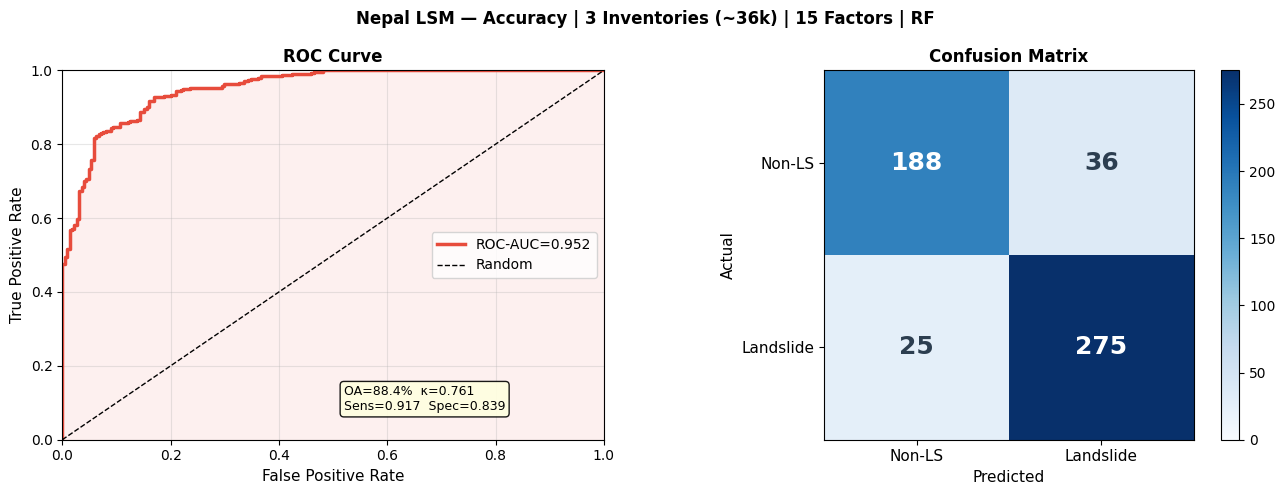

✅ Nepal_LSM_Accuracy.png saved


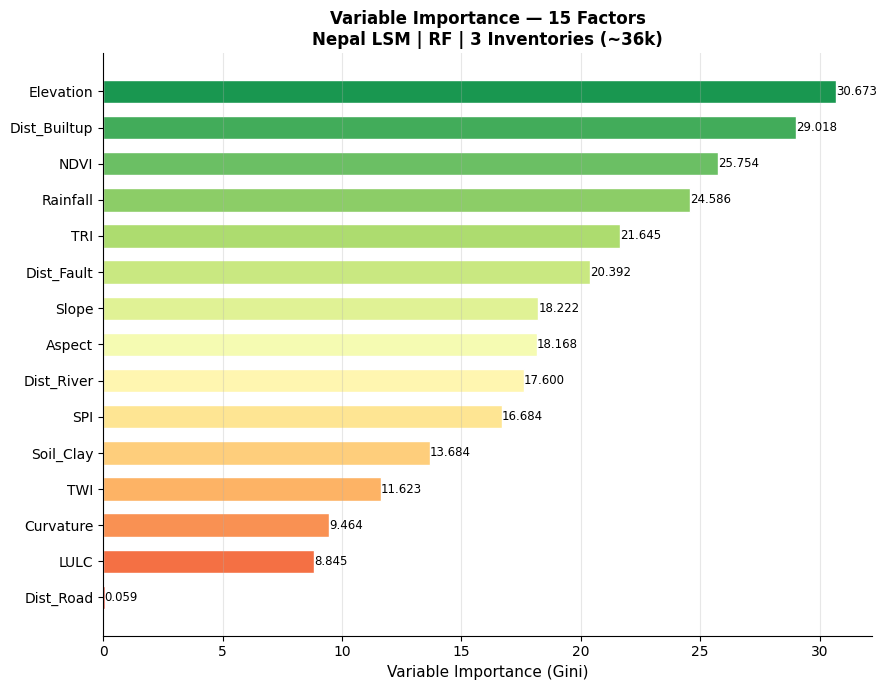

✅ Nepal_LSM_VarImportance.png saved

Generating publication map...
Sample columns: ['system:index', 'LSM_Probability', '.geo']
Map points: 6,588


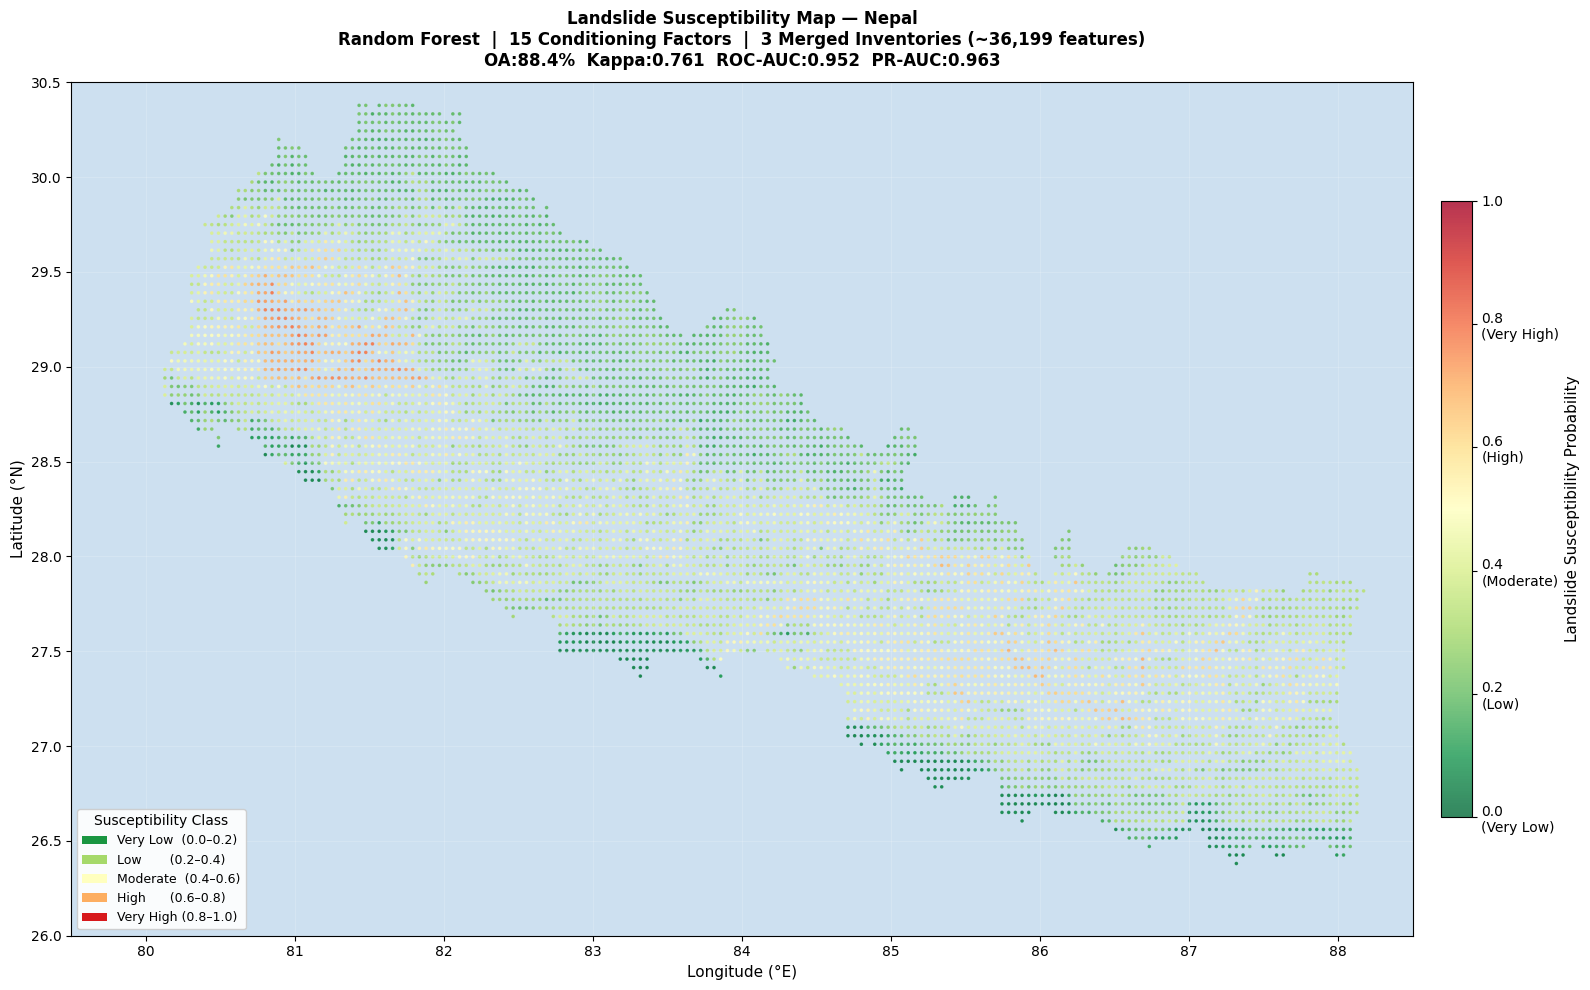

✅ Nepal_LSM_PublicationMap.png saved (300 DPI)

🎉 Session 2 complete! Output files:
   Nepal_LSM_Accuracy.png
   Nepal_LSM_VarImportance.png
   Nepal_LSM_PublicationMap.png


In [ ]:
# ================================================================
# RUN SESSION 2:
#
run_session2(
  test_csv_path       = '/content/Nepal_LSM_TestPredictions.csv',
  sample_csv_path     = '/content/Nepal_LSM_SamplePoints.csv',
  importance_csv_path = '/content/Nepal_LSM_VarImportance.csv'
)
# ================================================================